In [ ]:
!pip install --quiet langchain langchain-community langchain-text-splitters langchain-anthropic \
  faiss-cpu datasets tiktoken voyageai huggingface_hub --no-warn-conflicts


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 490.2/490.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 8.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from datasets import load_dataset

# Load CovidQA TEST subset from RAGBench
covidqa_test = load_dataset("galileo-ai/ragbench", "covidqa", split="test")
print(f"Loaded {len(covidqa_test)} CovidQA TEST examples")

# Load PubMedQA TEST subset from RAGBench
pubmedqa_test = load_dataset("galileo-ai/ragbench", "pubmedqa", split="test")
print(f"Loaded {len(pubmedqa_test)} PubMedQA TEST examples")

# Preview first example
print("\nExample from CovidQA test:")
covidqa_test[0]


Loaded 246 CovidQA TEST examples


pubmedqa/train-00000-of-00001.parquet:   0%|          | 0.00/80.1M [00:00<?, ?B/s]

pubmedqa/validation-00000-of-00001.parqu(…):   0%|          | 0.00/10.1M [00:00<?, ?B/s]

pubmedqa/test-00000-of-00001.parquet:   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2450 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2450 [00:00<?, ? examples/s]

Loaded 2450 PubMedQA TEST examples

Example from CovidQA test:


{'id': '1421',
 'question': 'Which viruses may not cause prolonged inflammation due to strong induction of antiviral clearance?',
 'documents': ['Title: Type I Interferon Receptor Deficiency in Dendritic Cells Facilitates Systemic Murine Norovirus Persistence Despite Enhanced Adaptive Immunity\nPassage: successful treatment for HCV serves to circumvent the viral inhibition of IFN induction. Thus, HCV may be an example of a medically relevant persistent viral infection that persists due, in part, to loss of innate immune function. Persistence of other continuously replicating RNA viruses, such as chikungunya, measles, polyomavirus, may be similarly due to ineffective innate responses.',
  'Title: Type I Interferon Response Is Delayed in Human Astrovirus Infections\nPassage: Results suggest that HAstV infection is not able to disrupt the innate immune sensing pathway induced by polyI:C . Only a previous infection with RV was able to reduce by 60% the IFN-β mRNA levels produced after poly

In [ ]:
import pandas as pd

def normalize_ragbench(dataset, source_name):
    """Convert RAGBench format to unified format"""
    records = []
    for row in dataset:
        # Combine all documents into one text block
        combined_docs = "\n\n".join([doc for doc in row["documents"]])

        records.append({
            "id": row["id"],
            "source": source_name,
            "text": combined_docs,
            "question": row["question"]
        })
    return records

# Normalize both TEST datasets
covid_records = normalize_ragbench(covidqa_test, "covidqa_test")
pubmed_records = normalize_ragbench(pubmedqa_test, "pubmedqa_test")

# Combine
#all_records = covid_records + pubmed_records
#df_all = pd.DataFrame(all_records)
df_all = pd.DataFrame(pubmed_records)

print(f"\nTotal TEST records: {len(df_all)}")
print(f"  - CovidQA test: {len(covid_records)}")
print(f"  - PubMedQA test: {len(pubmed_records)}")

# Save to CSV
df_all.to_csv("ragbench_test_combined.csv", index=False)
print("\n✓ Saved ragbench_test_combined.csv")

# Preview
df_all.head()



Total TEST records: 2450
  - CovidQA test: 246
  - PubMedQA test: 2450

✓ Saved ragbench_test_combined.csv


,id,source,text,question
0,pubmedqa_11200,pubmedqa_test,(1) Can surface porous PEEK (PEEK-SP) microstr...,Do Surface Porosity and Pore Size Influence Me...
1,pubmedqa_25899,pubmedqa_test,To evaluate placement of polyester (Dacron) co...,Does prosthetic covering of nitinol stents alt...
2,pubmedqa_623,pubmedqa_test,It has been demonstrated that there are a lot ...,Is diabetes mellitus a negative prognostic fac...
3,pubmedqa_51278,pubmedqa_test,A recently published and widely quoted modifie...,Do elderly persons need to be encouraged to dr...
4,pubmedqa_17849,pubmedqa_test,To evaluate the behavior of contact lens weare...,Do the economic and social factors play an imp...


In [ ]:
# Check schema and missing values
print("Dataset Info:")
df_all.info()

print("\nMissing values:")
print(df_all.isna().sum())

# Drop rows with empty text (if any)
df_all = df_all[df_all["text"].str.strip().astype(bool)]

# Save cleaned version
df_all.to_csv("ragbench_test_clean.csv", index=False)
print(f"\n✓ Cleaned dataset saved with {len(df_all)} records")

# Check final statistics
print("\nFinal dataset shape:", df_all.shape)
print("\nSample questions:")
print(df_all["question"].head(3).tolist())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2450 non-null   object
 1   source    2450 non-null   object
 2   text      2450 non-null   object
 3   question  2450 non-null   object
dtypes: object(4)
memory usage: 76.7+ KB

Missing values:
id          0
source      0
text        0
question    0
dtype: int64

✓ Cleaned dataset saved with 2450 records

Final dataset shape: (2450, 4)

Sample questions:
['Do Surface Porosity and Pore Size Influence Mechanical Properties and Cellular Response to PEEK?', 'Does prosthetic covering of nitinol stents alter healing characteristics or hemodynamics?', 'Is diabetes mellitus a negative prognostic factor for the treatment of advanced non-small-cell lung cancer?']


In [ ]:
!pip install --quiet langchain-experimental
!pip install -q langchain-huggingface sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 7.3 MB/s eta 0:00:00


In [ ]:
# =============================================================================
# IMPORTS AND NLTK SETUP
# =============================================================================

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from typing import List, Dict
import nltk
import copy

# Download BOTH punkt resources (newer NLTK versions need punkt_tab)
print("📥 Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)  # ← ADD THIS LINE
print("   ✓ NLTK data ready")

from nltk.tokenize import sent_tokenize


📥 Downloading NLTK data...
   ✓ NLTK data ready


In [ ]:
# =============================================================================
# CHUNKING
# =============================================================================

!pip install -q nltk langchain-experimental

# =============================================================================
# IMPORTS
# =============================================================================

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from typing import List, Dict
import nltk
import copy

# Download NLTK sentence tokenizer
nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize


# =============================================================================
# UPDATED CHUNKING CONFIGURATION - Now with 5 techniques
# =============================================================================

CHUNKING_CONFIGS = {
    # Technique 1: Fixed-size chunking (baseline)
    "fixed_512": {
        "chunk_size": 512,
        "chunk_overlap": 50,
        "description": "Fixed 512 tokens, minimal overlap"
    },

    # Technique 2: Your current setup (balanced)
    "recursive_600": {
        "chunk_size": 600,
        "chunk_overlap": 150,
        "description": "Recursive 600 tokens, sentence-aware"
    },

    # Technique 3: Small-to-Big (for precision)
    "small2big": {
        "small_chunk_size": 256,
        "big_chunk_size": 512,
        "chunk_overlap": 50,
        "description": "Small chunks (256) nested in big chunks (512)"
    },

    # Technique 4: Semantic Chunking (NEW)
    "semantic": {
        "breakpoint_type": "percentile",  # or "standard_deviation", "interquartile", "gradient"
        "breakpoint_threshold": 95,  # percentile threshold
        "description": "Embedding-based semantic boundary detection"
    },

    # Technique 5: NLTK Sentence Chunking (NEW)
    "nltk_sentences": {
        "max_sentences": 5,  # Group up to 5 sentences per chunk
        "max_words": 150,    # OR max 150 words per chunk
        "description": "NLTK sentence tokenization with word limit"
    }
}


# =============================================================================
# HELPER: NLTK SENTENCE CHUNKER
# =============================================================================

def nltk_sentence_chunking(
    docs: List[Document],
    max_sentences: int = 5,
    max_words: int = 150
) -> List[Document]:
    """
    Chunk documents using NLTK sentence tokenization.
    Groups sentences together up to max_sentences OR max_words limit.

    Args:
        docs: List of LangChain Document objects
        max_sentences: Maximum sentences per chunk
        max_words: Maximum words per chunk

    Returns:
        List of chunked Documents
    """

    chunked_docs = []
    chunk_index = 0

    for doc in docs:
        # Tokenize into sentences
        sentences = sent_tokenize(doc.page_content)

        buffer = []
        word_count = 0

        for sent in sentences:
            sent_words = len(sent.split())

            # Check if adding this sentence exceeds limits
            if (len(buffer) >= max_sentences or
                word_count + sent_words > max_words) and buffer:

                # Save current chunk
                chunk_text = " ".join(buffer)
                new_chunk = Document(
                    page_content=chunk_text,
                    metadata={
                        **doc.metadata,
                        "chunk_technique": "nltk_sentences",
                        "chunk_index": chunk_index,
                        "sentence_count": len(buffer),
                        "word_count": word_count
                    }
                )
                chunked_docs.append(new_chunk)
                chunk_index += 1

                # Reset buffer
                buffer = []
                word_count = 0

            # Add sentence to buffer
            buffer.append(sent)
            word_count += sent_words

        # Don't forget last chunk from this document
        if buffer:
            chunk_text = " ".join(buffer)
            new_chunk = Document(
                page_content=chunk_text,
                metadata={
                    **doc.metadata,
                    "chunk_technique": "nltk_sentences",
                    "chunk_index": chunk_index,
                    "sentence_count": len(buffer),
                    "word_count": word_count
                }
            )
            chunked_docs.append(new_chunk)
            chunk_index += 1

    return chunked_docs


# =============================================================================
# UPDATED MAIN CHUNKING FUNCTION - Now handles 5 techniques
# =============================================================================

def create_chunks_multi_technique(
    docs: List[Document],
    technique: str = "recursive_600",
    embeddings = None,  # Required for semantic chunking
    config: Dict = None
) -> List[Document]:
    """
    Create chunks using specified technique (now supports 5 methods).

    Args:
        docs: List of LangChain Document objects
        technique: One of ["fixed_512", "recursive_600", "small2big", "semantic", "nltk_sentences"]
        embeddings: Embedding model (required for "semantic" technique)
        config: Optional custom config dict

    Returns:
        List of chunked Document objects with metadata
    """

    if config is None:
        if technique not in CHUNKING_CONFIGS:
            raise ValueError(f"Unknown technique: {technique}. Choose from {list(CHUNKING_CONFIGS.keys())}")
        config = CHUNKING_CONFIGS[technique]

    print(f"🔹 Chunking technique: {technique}")
    print(f"   {config['description']}")

    # Common separators for sentence-aware chunking
    separators = ["\n\n", "\n", ". ", "! ", "? ", "; ", ", ", " ", ""]

    # ---------- TECHNIQUE 1 & 2: Fixed or Recursive ----------
    if technique in ["fixed_512", "recursive_600"]:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=config["chunk_size"],
            chunk_overlap=config["chunk_overlap"],
            length_function=len,
            separators=separators
        )

        chunked_docs = splitter.split_documents(docs)

        # Add metadata
        for i, chunk in enumerate(chunked_docs):
            chunk.metadata["chunk_technique"] = technique
            chunk.metadata["chunk_index"] = i
            chunk.metadata["chunk_size_config"] = config["chunk_size"]

        print(f"   ✓ Created {len(chunked_docs)} chunks from {len(docs)} documents")
        print(f"   ✓ Avg chunks per doc: {len(chunked_docs)/len(docs):.2f}")

        return chunked_docs

    # ---------- TECHNIQUE 3: Small-to-Big ----------
    elif technique == "small2big":
        small_size = config["small_chunk_size"]
        big_size = config["big_chunk_size"]
        overlap = config["chunk_overlap"]

        big_splitter = RecursiveCharacterTextSplitter(
            chunk_size=big_size,
            chunk_overlap=overlap,
            length_function=len,
            separators=separators
        )
        big_chunks = big_splitter.split_documents(docs)

        small_splitter = RecursiveCharacterTextSplitter(
            chunk_size=small_size,
            chunk_overlap=overlap // 2,
            length_function=len,
            separators=separators
        )

        final_chunks = []
        for big_idx, big_chunk in enumerate(big_chunks):
            small_chunks = small_splitter.split_text(big_chunk.page_content)

            for small_idx, small_text in enumerate(small_chunks):
                new_chunk = Document(
                    page_content=small_text,
                    metadata={
                        **big_chunk.metadata,
                        "chunk_technique": "small2big",
                        "small_chunk_index": small_idx,
                        "parent_chunk_index": big_idx,
                        "parent_chunk_text": big_chunk.page_content,
                        "small_chunk_size": small_size,
                        "big_chunk_size": big_size
                    }
                )
                final_chunks.append(new_chunk)

        print(f"   ✓ Created {len(final_chunks)} small chunks nested in {len(big_chunks)} big chunks")
        print(f"   ✓ Avg small chunks per big chunk: {len(final_chunks)/len(big_chunks):.2f}")

        return final_chunks

    # ---------- TECHNIQUE 4: SEMANTIC CHUNKING (NEW) ----------
    elif technique == "semantic":
        if embeddings is None:
            raise ValueError("Embeddings model required for semantic chunking. Pass embeddings parameter.")

        # Create SemanticChunker with LangChain's experimental module
        semantic_splitter = SemanticChunker(
            embeddings=embeddings,
            breakpoint_threshold_type=config["breakpoint_type"],
            breakpoint_threshold_amount=config.get("breakpoint_threshold")
        )

        # Split documents
        chunked_docs = semantic_splitter.split_documents(docs)

        # Add metadata
        for i, chunk in enumerate(chunked_docs):
            chunk.metadata["chunk_technique"] = "semantic"
            chunk.metadata["chunk_index"] = i
            chunk.metadata["breakpoint_type"] = config["breakpoint_type"]
            chunk.metadata["chunk_size"] = len(chunk.page_content)

        print(f"   ✓ Created {len(chunked_docs)} semantic chunks from {len(docs)} documents")
        print(f"   ✓ Avg chunks per doc: {len(chunked_docs)/len(docs):.2f}")

        # Show chunk size distribution
        chunk_sizes = [len(c.page_content) for c in chunked_docs]
        print(f"   ✓ Chunk size range: {min(chunk_sizes)} - {max(chunk_sizes)} chars")

        return chunked_docs

    # ---------- TECHNIQUE 5: NLTK SENTENCE CHUNKING (NEW) ----------
    elif technique == "nltk_sentences":
        chunked_docs = nltk_sentence_chunking(
            docs,
            max_sentences=config["max_sentences"],
            max_words=config["max_words"]
        )

        print(f"   ✓ Created {len(chunked_docs)} sentence-based chunks from {len(docs)} documents")
        print(f"   ✓ Avg chunks per doc: {len(chunked_docs)/len(docs):.2f}")

        return chunked_docs

    else:
        raise ValueError(f"Unknown chunking technique: {technique}")


# =============================================================================
# CREATE DOCUMENTS FROM YOUR DATAFRAME (unchanged)
# =============================================================================

docs = []
for _, row in df_all.iterrows():
    meta = {
        "id": row["id"],
        "source": row["source"],
        "question": row["question"]
    }
    docs.append(Document(page_content=row["text"], metadata=meta))

print(f"Created {len(docs)} documents")


# =============================================================================
# INITIALIZE EMBEDDINGS (Required for semantic chunking)
# =============================================================================

print("\n🔹 Loading embeddings model for semantic chunking...")
embeddings = HuggingFaceEmbeddings(
    model_name="pritamdeka/S-PubMedBert-MS-MARCO",
    model_kwargs={"device": "cpu"}
)
print("   ✓ Embeddings loaded")


# =============================================================================
# TEST ALL 5 TECHNIQUES
# =============================================================================

all_chunked_docs = {}

# Techniques to test
techniques_to_run = ["fixed_512", "recursive_600", "small2big",  "nltk_sentences"]

for technique_name in techniques_to_run:
    print("\n" + "="*80)

    try:
        # Semantic chunking needs embeddings parameter
        if technique_name == "semantic":
            chunked = create_chunks_multi_technique(
                docs,
                technique=technique_name,
                embeddings=embeddings  # Pass embeddings for semantic
            )
        else:
            chunked = create_chunks_multi_technique(docs, technique=technique_name)

        all_chunked_docs[technique_name] = chunked

        # Preview first chunk
        print(f"\n📄 First chunk preview:")
        print(f"   Length: {len(chunked[0].page_content)} chars")
        print(f"   Metadata keys: {list(chunked[0].metadata.keys())}")
        print(f"   Content: {chunked[0].page_content[:200]}...")

    except Exception as e:
        print(f"   ❌ Error: {e}")
        continue

print("\n" + "="*80)
print("✅ All chunking techniques ready!")
print(f"\nAvailable techniques:")
for tech in all_chunked_docs.keys():
    print(f"  - {tech}: {len(all_chunked_docs[tech])} chunks")


Created 2450 documents

🔹 Loading embeddings model for semantic chunking...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   ✓ Embeddings loaded

🔹 Chunking technique: fixed_512
   Fixed 512 tokens, minimal overlap
   ✓ Created 13502 chunks from 2450 documents
   ✓ Avg chunks per doc: 5.51

📄 First chunk preview:
   Length: 232 chars
   Metadata keys: ['id', 'source', 'question', 'chunk_technique', 'chunk_index', 'chunk_size_config']
   Content: (1) Can surface porous PEEK (PEEK-SP) microstructure be reliably controlled? (2) What is the effect of pore size on the mechanical properties of PEEK-SP? (3) Do surface porosity and pore size influenc...

🔹 Chunking technique: recursive_600
   Recursive 600 tokens, sentence-aware
   ✓ Created 11538 chunks from 2450 documents
   ✓ Avg chunks per doc: 4.71

📄 First chunk preview:
   Length: 232 chars
   Metadata keys: ['id', 'source', 'question', 'chunk_technique', 'chunk_index', 'chunk_size_config']
   Content: (1) Can surface porous PEEK (PEEK-SP) microstructure be reliably controlled? (2) What is the effect of pore size on the mechanical properties of PEEK-SP? (3

In [ ]:
!pip install -q langchain-huggingface sentence-transformers
!pip install -q sentence-transformers transformers torch rank-bm25
!pip install -q langchain langchain-community
!pip install -q langchain



In [ ]:
# Verify installations
!pip list | grep langchain


langchain                                1.2.4
langchain-anthropic                      1.3.1
langchain-classic                        1.0.1
langchain-community                      0.4.1
langchain-core                           1.2.7
langchain-experimental                   0.4.1
langchain-huggingface                    1.2.0
langchain-text-splitters                 1.1.0


In [ ]:
# ============================================================================
# FIX: Update SimpleEnsembleRetriever class
# ============================================================================

class SimpleEnsembleRetriever:
    """Simple Ensemble Retriever using Reciprocal Rank Fusion"""

    def __init__(self, retrievers: List, weights: List[float] = None, k: int = 60):
        self.retrievers = retrievers
        self.weights = weights or [1.0 / len(retrievers)] * len(retrievers)
        self.k = k  # RRF constant

    def get_relevant_documents(self, query: str, k: int = 10) -> List[Document]:
        """Retrieve documents using Reciprocal Rank Fusion"""

        # Get results from each retriever
        all_results = []
        for retriever in self.retrievers:
            # ✅ FIX: Use invoke() instead of get_relevant_documents()
            try:
                docs = retriever.invoke(query)  # New method
            except AttributeError:
                docs = retriever.get_relevant_documents(query)  # Fallback for older versions
            all_results.append(docs)

        # Apply Reciprocal Rank Fusion
        doc_scores = {}
        doc_map = {}

        for weight, docs in zip(self.weights, all_results):
            for rank, doc in enumerate(docs):
                doc_id = hash(doc.page_content)
                if doc_id not in doc_map:
                    doc_map[doc_id] = doc

                # RRF formula: weight / (k + rank)
                score = weight / (self.k + rank + 1)
                doc_scores[doc_id] = doc_scores.get(doc_id, 0) + score

        # Sort by score and return top k
        sorted_doc_ids = sorted(doc_scores.keys(),
                               key=lambda x: doc_scores[x],
                               reverse=True)

        return [doc_map[doc_id] for doc_id in sorted_doc_ids[:k]]


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

# Use free local embeddings (no API key required)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)





# embeddings = HuggingFaceEmbeddings(
#     model_name="pritamdeka/S-PubMedBert-MS-MARCO",  # Trained on PubMed
#     model_kwargs={'device': 'cpu'}
# )


print("✓ HuggingFace embeddings initialized (running locally)")

✓ HuggingFace embeddings initialized (running locally)


In [ ]:
from langchain_community.vectorstores import FAISS
import os

# =============================================================================
# CREATE 4 FAISS INDEXES
# =============================================================================

vectorstores = {}
os.makedirs("./ragbench_indexes", exist_ok=True)

for technique, chunks in all_chunked_docs.items():
    print(f"\n{'='*80}")
    print(f"🔹 Creating FAISS index: {technique}")
    print(f"   Indexing {len(chunks):,} chunks...")

    # Create vector store
    vs = FAISS.from_documents(chunks, embeddings)

    # Save to disk
    index_path = f"./ragbench_indexes/faiss_{technique}"
    vs.save_local(index_path)

    # Store in memory
    vectorstores[technique] = vs

    print(f"   ✓ Index created: {len(chunks):,} vectors")
    print(f"   ✓ Saved to: {index_path}")

print("\n" + "="*80)
print("✅ All 4 FAISS indexes ready!")
print(f"\nIndexes created:")
for tech, vs in vectorstores.items():
    print(f"  - {tech}: {vs.index.ntotal:,} vectors")



🔹 Creating FAISS index: fixed_512
   Indexing 13,502 chunks...
   ✓ Index created: 13,502 vectors
   ✓ Saved to: ./ragbench_indexes/faiss_fixed_512

🔹 Creating FAISS index: recursive_600
   Indexing 11,538 chunks...
   ✓ Index created: 11,538 vectors
   ✓ Saved to: ./ragbench_indexes/faiss_recursive_600

🔹 Creating FAISS index: small2big
   Indexing 27,062 chunks...
   ✓ Index created: 27,062 vectors
   ✓ Saved to: ./ragbench_indexes/faiss_small2big

🔹 Creating FAISS index: nltk_sentences
   Indexing 7,054 chunks...
   ✓ Index created: 7,054 vectors
   ✓ Saved to: ./ragbench_indexes/faiss_nltk_sentences

✅ All 4 FAISS indexes ready!

Indexes created:
  - fixed_512: 13,502 vectors
  - recursive_600: 11,538 vectors
  - small2big: 27,062 vectors
  - nltk_sentences: 7,054 vectors


In [ ]:
# from langchain_community.vectorstores import FAISS

# # Create FAISS vector store
# print("Creating FAISS index... (this may take a few minutes)")
# vectorstore = FAISS.from_documents(chunked_docs, embeddings)

# # Save index
# vectorstore.save_local("ragbench_test_faiss_index")
# print("✓ Index saved to ragbench_test_faiss_index/")

# # Test retrieval
# test_query = "What are the effects of COVID-19 on cardiovascular health?"
# test_results = vectorstore.similarity_search(test_query, k=3)

# print(f"\nTest retrieval for: '{test_query}'")
# print(f"Retrieved {len(test_results)} chunks")
# print(f"First result source: {test_results[0].metadata['source']}")


# for i, doc in enumerate(test_results, start=1):
#     print("=" * 80)
#     print(f"Result #{i}")
#     print(f"Source   : {doc.metadata.get('source', 'N/A')}")
#     print(f"Metadata : {doc.metadata}")
#     print("\nContent:")
#     print(doc.page_content)
#     print()


Creating FAISS index... (this may take a few minutes)
✓ Index saved to ragbench_test_faiss_index/

Test retrieval for: 'What are the effects of COVID-19 on cardiovascular health?'
Retrieved 3 chunks
First result source: pubmedqa_test
Result #1
Source   : pubmedqa_test
Metadata : {'id': 'pubmedqa_18781', 'source': 'pubmedqa_test', 'question': 'Do simple prudent health behaviours protect men from myocardial infarction?'}

Content:
. Follow-up was for 12 years, and both fatal and non-fatal cardiovascular events (MI, stroke or MI, and stroke) were recorded. After adjustment for age and other confounders, men in the highest third of vigorous physical activity experienced decreased risk of MI, relative to men in the lowest third; hazard ratios (HR) (95% CI) were 0.71 (0.50, 1.03), 0.42 (0.19, 0.92), and 0.60 (0.38, 0.94) in men with symptomatic, asymptomatic coronary heart disease (CHD), and no evidence of CHD at baseline, respectively

Result #2
Source   : pubmedqa_test
Metadata : {'id': 'p

In [ ]:
# ============================================================================
# COMPLETE WORKING CODE - Ready to use in your notebook
# ============================================================================

from sentence_transformers import CrossEncoder
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch
from typing import List
from langchain_core.documents import Document
from langchain_community.retrievers.bm25 import BM25Retriever

# ============================================================================
# 1. LOAD RERANKING MODELS
# ============================================================================

print("🔹 Loading CrossEncoder reranker...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L6-v2')
print("✅ CrossEncoder loaded")

print("🔹 Loading MonoT5 reranker...")
monot5_model_name = 'castorini/monot5-base-msmarco'
monot5_tokenizer = T5Tokenizer.from_pretrained(monot5_model_name)
monot5_model = T5ForConditionalGeneration.from_pretrained(monot5_model_name)
monot5_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
monot5_model = monot5_model.to(device)
print(f"✅ MonoT5 loaded on {device}")

# ============================================================================
# 2. RERANKING FUNCTIONS
# ============================================================================

def rerank_crossencoder(query: str, documents: List[Document], top_k: int = 10) -> List[Document]:
    """Rerank documents using CrossEncoder"""
    if not documents:
        return []

    pairs = [(query, doc.page_content) for doc in documents]
    scores = cross_encoder.predict(pairs)

    scored_docs = list(zip(documents, scores))
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    reranked_docs = []
    for doc, score in scored_docs[:top_k]:
        doc_copy = Document(
            page_content=doc.page_content,
            metadata={**doc.metadata, 'rerank_score': float(score)}
        )
        reranked_docs.append(doc_copy)

    return reranked_docs

def rerank_monot5(query: str, documents: List[Document], top_k: int = 10) -> List[Document]:
    """Rerank documents using MonoT5"""
    if not documents:
        return []

    scores = []
    for doc in documents:
        input_text = f"Query: {query} Document: {doc.page_content} Relevant:"

        inputs = monot5_tokenizer(
            input_text,
            max_length=512,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = monot5_model.generate(
                **inputs,
                max_new_tokens=1,
                return_dict_in_generate=True,
                output_scores=True
            )

            logits = outputs.scores[0][0]
            true_token_id = monot5_tokenizer.encode('true')[0]
            false_token_id = monot5_tokenizer.encode('false')[0]

            true_score = logits[true_token_id].item()
            false_score = logits[false_token_id].item()

            score = torch.exp(torch.tensor(true_score)) / (
                torch.exp(torch.tensor(true_score)) + torch.exp(torch.tensor(false_score))
            )
            scores.append(score.item())

    scored_docs = list(zip(documents, scores))
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    reranked_docs = []
    for doc, score in scored_docs[:top_k]:
        doc_copy = Document(
            page_content=doc.page_content,
            metadata={**doc.metadata, 'rerank_score': float(score)}
        )
        reranked_docs.append(doc_copy)

    return reranked_docs

# ============================================================================
# 3. RETRIEVAL FUNCTIONS
# ============================================================================

def create_hybrid_retriever(documents: List[Document], vectorstore, alpha: float = 0.7, k: int = 10):
    """Create hybrid retriever using SimpleEnsembleRetriever"""

    bm25_retriever = BM25Retriever.from_documents(documents)
    bm25_retriever.k = k

    dense_retriever = vectorstore.as_retriever(search_kwargs={"k": k})

    ensemble = SimpleEnsembleRetriever(
        retrievers=[bm25_retriever, dense_retriever],
        weights=[1-alpha, alpha]
    )

    return ensemble

def retrieve_mmr(vectorstore, query: str, k: int = 10, fetch_k: int = 20, lambda_mult: float = 0.5) -> List[Document]:
    """Max Marginal Relevance search for diversity"""
    docs = vectorstore.max_marginal_relevance_search(
        query=query,
        k=k,
        fetch_k=fetch_k,
        lambda_mult=lambda_mult
    )
    return docs

def retrieve_similarity(vectorstore, query: str, k: int = 10) -> List[Document]:
    """Standard cosine similarity search"""
    docs = vectorstore.similarity_search(query=query, k=k)
    return docs

# ============================================================================
# 4. MAIN EVALUATION FUNCTION
# ============================================================================

def evaluate_retrieval_reranking_combination(
    query: str,
    vectorstore,
    all_documents: List[Document],
    retrieval_method: str = 'mmr',
    reranking_method: str = 'crossencoder',
    k_retrieve: int = 50,
    k_final: int = 10
) -> List[Document]:
    """
    Complete pipeline for RAGBench evaluation

    Args:
        query: Query string
        vectorstore: Your FAISS vectorstore
        all_documents: List of all Document objects
        retrieval_method: 'mmr', 'similarity', or 'hybrid'
        reranking_method: 'crossencoder', 'monot5', or 'none'
        k_retrieve: Number of docs to retrieve initially
        k_final: Number of docs after reranking
    """

    # STEP 1: Retrieval
    print(f"🔹 Retrieval: {retrieval_method} (k={k_retrieve})")

    if retrieval_method == 'mmr':
        retrieved_docs = retrieve_mmr(vectorstore, query, k=k_retrieve, fetch_k=k_retrieve*2)

    elif retrieval_method == 'similarity':
        retrieved_docs = retrieve_similarity(vectorstore, query, k=k_retrieve)

    elif retrieval_method == 'hybrid':
        hybrid_retriever = create_hybrid_retriever(all_documents, vectorstore, alpha=0.7, k=k_retrieve)
        retrieved_docs = hybrid_retriever.get_relevant_documents(query)

    else:
        raise ValueError(f"Unknown retrieval method: {retrieval_method}")

    print(f"   ✓ Retrieved {len(retrieved_docs)} documents")

    # STEP 2: Reranking
    if reranking_method == 'none':
        final_docs = retrieved_docs[:k_final]
        print(f"   ✓ No reranking, using top {k_final}")

    elif reranking_method == 'crossencoder':
        print(f"🔹 Reranking: CrossEncoder (top {k_final})")
        final_docs = rerank_crossencoder(query, retrieved_docs, top_k=k_final)
        print(f"   ✓ Reranked to {len(final_docs)} documents")

    elif reranking_method == 'monot5':
        print(f"🔹 Reranking: MonoT5 (top {k_final})")
        final_docs = rerank_monot5(query, retrieved_docs, top_k=k_final)
        print(f"   ✓ Reranked to {len(final_docs)} documents")

    else:
        raise ValueError(f"Unknown reranking method: {reranking_method}")

    return final_docs

print("\n✅ All retrieval and reranking methods loaded!")
print("\nAvailable methods:")
print("  Retrieval: 'mmr', 'similarity', 'hybrid'")
print("  Reranking: 'crossencoder', 'monot5', 'none'")


🔹 Loading CrossEncoder reranker...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

✅ MonoT5 loaded on cuda

✅ All retrieval and reranking methods loaded!

Available methods:
  Retrieval: 'mmr', 'similarity', 'hybrid'
  Reranking: 'crossencoder', 'monot5', 'none'


In [ ]:
!pip install -U langchain langchain-community

In [ ]:
!pip install -q langchain-groq

In [ ]:
from google.colab import userdata
import os

# Retrieve the API key from Colab secrets
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
print("✓ API key loaded from Colab secrets")


key = os.environ.get("GROQ_API_KEY", "")
if key:
    print(f"✓ Key loaded: {key[:4]}...{key[-4:]}")
else:
    print("✗ Key not found")

✓ API key loaded from Colab secrets
✓ Key loaded: gsk_...ynqt


In [ ]:
# from langchain_core.documents import Document
# from transformers import T5Tokenizer, T5ForConditionalGeneration
# import torch
# from typing import List

# class MonoT5Reranker:
#     """LangChain-compatible monoT5 reranker"""

#     def __init__(self, model_name: str = "castorini/monot5-base-msmarco"):
#         """Initialize monoT5 model"""
#         print(f"Loading {model_name}...")
#         self.tokenizer = T5Tokenizer.from_pretrained(model_name)
#         self.model = T5ForConditionalGeneration.from_pretrained(model_name)
#         self.model.eval()

#         # Move to GPU if available
#         self.device = "cuda" if torch.cuda.is_available() else "cpu"
#         self.model.to(self.device)
#         print(f"✓ MonoT5 loaded on {self.device}")

#     def rerank(self, query: str, documents: List[Document], top_k: int = 5) -> List[Document]:
#         """
#         Rerank documents using monoT5

#         Args:
#             query: User question
#             documents: List of LangChain Document objects
#             top_k: Number of documents to return

#         Returns:
#             Reranked List[Document] with scores in metadata
#         """
#         scores = []

#         for doc in documents:
#             # Format: "Query: <q> Document: <d> Relevant:"
#             input_text = f"Query: {query} Document: {doc.page_content[:512]} Relevant:"
#             input_ids = self.tokenizer(
#                 input_text,
#                 return_tensors="pt",
#                 truncation=True,
#                 max_length=512
#             ).input_ids.to(self.device)

#             with torch.no_grad():
#                 outputs = self.model.generate(
#                     input_ids,
#                     max_length=2,
#                     return_dict_in_generate=True,
#                     output_scores=True
#                 )

#                 # Get probability of "true" token
#                 logits = outputs.scores[0][0]
#                 true_token_id = self.tokenizer.encode("true")[0]
#                 false_token_id = self.tokenizer.encode("false")[0]

#                 # Compute softmax probability
#                 score = torch.softmax(
#                     torch.tensor([logits[false_token_id], logits[true_token_id]]),
#                     dim=0
#                 )[1].item()

#             scores.append(score)

#         # Sort documents by score (descending)
#         doc_scores = list(zip(documents, scores))
#         doc_scores.sort(key=lambda x: x[1], reverse=True)

#         # Add scores to metadata and return top-k
#         reranked_docs = []
#         for doc, score in doc_scores[:top_k]:
#             doc.metadata['rerank_score'] = float(score)
#             reranked_docs.append(doc)

#         return reranked_docs

# # Initialize reranker
# monot5_reranker = MonoT5Reranker()

# # Test it
# test_docs = vectorstore.similarity_search("COVID-19 vaccine effectiveness", k=10)
# reranked = monot5_reranker.rerank(
#     query="COVID-19 vaccine effectiveness",
#     documents=test_docs,
#     top_k=5
# )

# print(f"✓ Reranked {len(reranked)} docs")
# print(f"Top score: {reranked[0].metadata['rerank_score']:.4f}")


Loading castorini/monot5-base-msmarco...
✓ MonoT5 loaded on cuda
✓ Reranked 5 docs
Top score: 0.0000


In [ ]:
def repack_documents(documents: list, method: str = "reverse") -> list:
    """
    Repack documents according to specified strategy

    Args:
        documents: List of reranked Document objects
        method: "forward" (most relevant first), "reverse" (most relevant last),
                or "sides" (most relevant at start and end)

    Returns:
        Repacked list of Document objects
    """
    if method == "forward":
        return documents

    elif method == "reverse":
        # RECOMMENDED by paper
        return list(reversed(documents))

    elif method == "sides":
        if len(documents) <= 2:
            return documents

        repacked = []
        for i in range(len(documents)):
            if i % 2 == 0:
                repacked.append(documents[i // 2])
            else:
                repacked.append(documents[-(i // 2 + 1)])

        return repacked

    else:
        raise ValueError(f"Unknown repacking method: {method}")

print("✓ Repacking function ready")


✓ Repacking function ready


In [ ]:
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.output_parsers import StrOutputParser

# def enhanced_rag_pipeline(
#     query: str,
#     vectorstore,
#     llm,
#     retrieval_k: int = 5,
#     rerank_k: int = 5,
#     repack_method: str = "reverse"
# ) -> dict:
#     """
#     Complete RAG pipeline with MonoT5 reranking, repacking, and summarization
#     """
#     print(f"Processing query: {query}\n")

#     # Step 1: Initial Retrieval
#     print(f"1. Retrieving top-{retrieval_k} documents...")
#     retrieved_docs = vectorstore.similarity_search(query, k=retrieval_k)

#     print(f"   Retrieved {len(retrieved_docs)} documents")

#     # Step 2: Reranking with MonoT5 ← CHANGED: use your monot5_reranker
#     print(f"2. Reranking with MonoT5 to top-{rerank_k}...")
#     reranked_docs = monot5_reranker.rerank(query, retrieved_docs, top_k=rerank_k)
#     print(f"   Reranked to {len(reranked_docs)} documents")
#     print(f"   Top rerank score: {reranked_docs[0].metadata.get('rerank_score', 'N/A'):.4f}")

#     # Step 3: Repacking
#     print(f"3. Repacking documents ({repack_method} method)...")
#     repacked_docs = repack_documents(reranked_docs, method=repack_method)
#     print(f"   Repacked {len(repacked_docs)} documents")

#     context = "\n\n".join([
#         f"[Source: {doc.metadata.get('source', '')} | ID: {doc.metadata.get('id', '')}]\n{doc.page_content}"
#         for doc in repacked_docs
#     ])

#     # Step 5: Generate Answer
#     print("5. Generating answer...")
#     prompt = ChatPromptTemplate.from_template(
#         """You are a helpful medical research assistant specializing in COVID-19 and biomedical literature.

# Use the following context to answer the question accurately and concisely.
# Cite specific information from the context.

# Context:
# {context}

# Question: {question}

# Provide a clear, evidence-based answer:"""
#     )

#     chain = prompt | llm | StrOutputParser()
#     answer = chain.invoke({"context": context, "question": query})

#     print("✓ Answer generated\n")

#     return {
#         "answer": answer,
#         "retrieved_count": len(retrieved_docs),
#         "reranked_count": len(reranked_docs),
#         "repacked_docs": repacked_docs,
#         "context_used": context
#     }

# print("✓ Enhanced RAG pipeline ready with MonoT5!")


✓ Enhanced RAG pipeline ready with MonoT5!


In [ ]:
# ============================================================================
# FIX: Update the hybrid retrieval section
# ============================================================================

def evaluate_retrieval_reranking_combination(
    query: str,
    vectorstore,
    all_documents: List[Document],
    retrieval_method: str = 'mmr',
    reranking_method: str = 'crossencoder',
    k_retrieve: int = 50,
    k_final: int = 10
) -> List[Document]:
    """Complete pipeline for RAGBench evaluation"""

    # STEP 1: Retrieval
    print(f"🔹 Retrieval: {retrieval_method} (k={k_retrieve})")

    if retrieval_method == 'mmr':
        retrieved_docs = retrieve_mmr(vectorstore, query, k=k_retrieve, fetch_k=k_retrieve*2)

    elif retrieval_method == 'similarity':
        retrieved_docs = retrieve_similarity(vectorstore, query, k=k_retrieve)

    elif retrieval_method == 'hybrid':
        hybrid_retriever = create_hybrid_retriever(all_documents, vectorstore, alpha=0.7, k=k_retrieve)
        # ✅ FIX: Use invoke() instead of get_relevant_documents()
        try:
            retrieved_docs = hybrid_retriever.invoke(query)
        except AttributeError:
            retrieved_docs = hybrid_retriever.get_relevant_documents(query)

    else:
        raise ValueError(f"Unknown retrieval method: {retrieval_method}")

    print(f"   ✓ Retrieved {len(retrieved_docs)} documents")

    # STEP 2: Reranking (unchanged)
    if reranking_method == 'none':
        final_docs = retrieved_docs[:k_final]
        print(f"   ✓ No reranking, using top {k_final}")

    elif reranking_method == 'crossencoder':
        print(f"🔹 Reranking: CrossEncoder (top {k_final})")
        final_docs = rerank_crossencoder(query, retrieved_docs, top_k=k_final)
        print(f"   ✓ Reranked to {len(final_docs)} documents")

    elif reranking_method == 'monot5':
        print(f"🔹 Reranking: MonoT5 (top {k_final})")
        final_docs = rerank_monot5(query, retrieved_docs, top_k=k_final)
        print(f"   ✓ Reranked to {len(final_docs)} documents")

    else:
        raise ValueError(f"Unknown reranking method: {reranking_method}")

    return final_docs


In [ ]:
# ============================================================================
# QUICK TEST: Verify all techniques work
# ============================================================================

# Use your existing loaded data
test_query = "What are the symptoms of COVID-19?"  # Change to your domain

# Test 1: Similarity + No reranking (baseline)
print("\n" + "="*80)
print("TEST 1: Similarity + No Reranking")
print("="*80)
docs1 = evaluate_retrieval_reranking_combination(
    query=test_query,
    vectorstore=vectorstores['recursive_600'],  # Use your loaded vectorstore
    all_documents=all_chunked_docs['recursive_600'],  # Use your chunked docs
    retrieval_method='similarity',
    reranking_method='none',
    k_retrieve=10,
    k_final=10
)
print(f"✅ Got {len(docs1)} documents")

# Test 2: Hybrid + CrossEncoder
print("\n" + "="*80)
print("TEST 2: Hybrid + CrossEncoder")
print("="*80)
docs2 = evaluate_retrieval_reranking_combination(
    query=test_query,
    vectorstore=vectorstores['recursive_600'],
    all_documents=all_chunked_docs['recursive_600'],
    retrieval_method='hybrid',
    reranking_method='crossencoder',
    k_retrieve=50,
    k_final=10
)
print(f"✅ Got {len(docs2)} documents")
print(f"Top doc rerank score: {docs2[0].metadata.get('rerank_score', 'N/A'):.4f}")

print("\n🎉 All tests passed! Ready for full evaluation.")



TEST 1: Similarity + No Reranking


NameError: name 'vectorstores' is not defined

In [ ]:
# ============================================================================
# COMPLETE MULTI-DOMAIN EVALUATION - READY TO RUN
# ============================================================================

from datasets import load_dataset
from tqdm import tqdm
import json
import pandas as pd
import os
import time
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

# ============================================================================
# CONFIGURATION
# ============================================================================

# Complete domain configuration (12 datasets)
DOMAIN_CONFIGS = {
    # Medical (2)
    # 'medical_covidqa': {
    #     'dataset_name': 'covidqa',
    #     'split': 'test',
    #     'description': 'COVID-19 research papers Q&A'
    # },
    'medical_pubmedqa': {
        'dataset_name': 'pubmedqa',
        'split': 'test',
        'description': 'Biomedical research - PubMed abstracts'
    },

    # Finance (2)
    'finance_finqa': {
        'dataset_name': 'finqa',
        'split': 'test',
        'description': 'Financial reasoning with numerical data'
    },
    # 'finance_tatqa': {
    #     'dataset_name': 'tatqa',
    #     'split': 'test',
    #     'description': 'Tabular and textual data from financial reports'
    # },

    # Customer Support (3)
    'support_techqa': {
        'dataset_name': 'techqa',
        'split': 'test',
        'description': 'Technical support - IBM forums'
    },
    # 'support_emanual': {
    #     'dataset_name': 'emanual',
    #     'split': 'test',
    #     'description': 'User manuals and product documentation'
    # },
    # 'support_delucionqa': {
    #     'dataset_name': 'delucionqa',
    #     'split': 'test',
    #     'description': 'Customer support queries'
    # },

    # General Knowledge (4)
    'general_hotpotqa': {
        'dataset_name': 'hotpotqa',
        'split': 'test',
        'description': 'Multi-hop reasoning over Wikipedia'
    },
    # 'general_msmarco': {
    #     'dataset_name': 'msmarco',
    #     'split': 'test',
    #     'description': 'Web search queries - diverse topics'
    # },
    # 'general_hagrid': {
    #     'dataset_name': 'hagrid',
    #     'split': 'test',
    #     'description': 'Human-annotated conversational retrieval'
    # },
    # 'general_expertqa': {
    #     'dataset_name': 'expertqa',
    #     'split': 'test',
    #     'description': 'Expert-level questions from science/arts/law'
    # },

    # Legal (1)
    'legal_cuad': {
        'dataset_name': 'cuad',
        'split': 'test',
        'description': 'Legal contracts - clause extraction'
    },
}

CHUNKING_TECHNIQUES = [
    'recursive_600',
    'small2big',
    'nltk_sentences',
    'fixed_512'
]

RETRIEVAL_RERANKING_COMBOS = [
    ('similarity', 'none', 'Baseline'),
    ('mmr', 'crossencoder', 'MMR+CrossEncoder'),
    ('hybrid', 'crossencoder', 'Hybrid+CrossEncoder'),
]

K_RETRIEVE = 50
K_FINAL = 10
NUM_QUESTIONS = 30  # Per dataset

# ============================================================================
# STEP 1: LOAD AND PREPARE ALL DOMAIN DATASETS
# ============================================================================

print(f"{'='*80}")
print(f"🌍 LOADING DATASETS FROM ALL DOMAINS")
print(f"{'='*80}\n")

domain_datasets = {}

for domain_key, config in DOMAIN_CONFIGS.items():
    print(f"Loading {domain_key}: {config['dataset_name']}...")
    try:
        dataset_full = load_dataset(
            'galileo-ai/ragbench',
            config['dataset_name'],
            split=config['split']
        )
        # Take first 30 questions for evaluation
        num_samples = min(NUM_QUESTIONS, len(dataset_full))
        domain_datasets[domain_key] = {
            'dataset': dataset_full.select(range(num_samples)),
            'config': config,
            'full_size': len(dataset_full)
        }
        print(f"  ✓ Loaded {num_samples}/{len(dataset_full)} questions")
    except Exception as e:
        print(f"  ✗ Error loading {domain_key}: {e}")
        continue

print(f"\n✅ Successfully loaded {len(domain_datasets)}/{len(DOMAIN_CONFIGS)} datasets")
print(f"{'='*80}\n")

# ============================================================================
# STEP 2: CREATE DOCUMENTS AND CHUNKS FOR ALL DOMAINS
# ============================================================================

print(f"{'='*80}")
print(f"📦 CREATING CHUNKS FOR ALL DOMAINS")
print(f"{'='*80}\n")

all_domain_data = {}

for domain_key, domain_info in domain_datasets.items():
    print(f"\n{'─'*80}")
    print(f"Processing: {domain_key}")
    print(f"Dataset: {domain_info['config']['dataset_name']}")
    print(f"{'─'*80}")

    dataset = domain_info['dataset']

    # Create documents from dataset
    docs = []
    for row in dataset:
        # Combine all documents into one text block (RAGBench format)
        combined_docs = "\n\n".join(doc for doc in row['documents'])

        meta = {
            'id': row['id'],
            'source': domain_info['config']['dataset_name'],
            'question': row['question'],
            'domain': domain_key
        }

        docs.append(Document(page_content=combined_docs, metadata=meta))

    print(f"  ✓ Created {len(docs)} documents")

    # Create chunks with all techniques
    domain_chunks = {}

    for technique in CHUNKING_TECHNIQUES:
        print(f"  📝 Chunking with {technique}...", end=" ")

        try:
            # Use your existing create_chunks_multi_technique function
            chunked = create_chunks_multi_technique(
                docs,
                technique=technique,
                embeddings=embeddings if technique == 'semantic' else None
            )
            domain_chunks[technique] = chunked
            print(f"✓ {len(chunked)} chunks")
        except Exception as e:
            print(f"✗ Error: {str(e)[:50]}")
            continue

    # Create FAISS indexes for all chunking techniques
    domain_vectorstores = {}

    for technique, chunks in domain_chunks.items():
        print(f"  🔍 Indexing {technique}...", end=" ")
        try:
            vs = FAISS.from_documents(chunks, embeddings)
            domain_vectorstores[technique] = vs
            print(f"✓ {vs.index.ntotal} vectors")
        except Exception as e:
            print(f"✗ Error: {str(e)[:50]}")
            continue

    # Store everything for this domain
    all_domain_data[domain_key] = {
        'dataset': dataset,
        'documents': docs,
        'chunks': domain_chunks,
        'vectorstores': domain_vectorstores,
        'config': domain_info['config']
    }

    print(f"  ✅ {domain_key} ready: {len(domain_vectorstores)} indexes created")

print(f"\n{'='*80}")
print(f"✅ ALL DOMAINS PREPARED")
print(f"  Total domains: {len(all_domain_data)}")
print(f"  Chunking techniques: {len(CHUNKING_TECHNIQUES)}")
print(f"  Retrieval combos: {len(RETRIEVAL_RERANKING_COMBOS)}")
print(f"{'='*80}\n")

# ============================================================================
# STEP 3: COMPREHENSIVE EVALUATION
# ============================================================================

print(f"{'='*80}")
print(f"🚀 STARTING COMPREHENSIVE MULTI-DOMAIN EVALUATION")
print(f"{'='*80}\n")

# Calculate totals
total_experiments = len(all_domain_data) * len(CHUNKING_TECHNIQUES) * len(RETRIEVAL_RERANKING_COMBOS)
total_queries = total_experiments * NUM_QUESTIONS

print(f"📊 Evaluation Scope:")
print(f"  Domains/Datasets: {len(all_domain_data)}")
print(f"  Chunking techniques: {len(CHUNKING_TECHNIQUES)}")
print(f"  Retrieval/Reranking combos: {len(RETRIEVAL_RERANKING_COMBOS)}")
print(f"  Questions per experiment: {NUM_QUESTIONS}")
print(f"  {'─'*60}")
print(f"  Total experiments: {total_experiments}")
print(f"  Total queries: {total_queries}")
print(f"  {'─'*60}")
print(f"  Estimated time: ~{total_queries/300:.1f}-{total_queries/150:.1f} minutes")
print(f"{'='*80}\n")

# Storage
all_experiment_results = []
detailed_results = {}
current_experiment = 0

# ============================================================================
# MAIN EVALUATION LOOP
# ============================================================================

for domain_key, domain_data in all_domain_data.items():

    print(f"\n{'='*80}")
    print(f"📊 DOMAIN: {domain_key.upper()}")
    print(f"   {domain_data['config']['description']}")
    print(f"{'='*80}")

    dataset = domain_data['dataset']
    chunks_dict = domain_data['chunks']
    vectorstores_dict = domain_data['vectorstores']

    for chunking_technique in CHUNKING_TECHNIQUES:

        if chunking_technique not in vectorstores_dict:
            print(f"⚠️  Skipping {chunking_technique} - not available")
            continue

        print(f"\n{'─'*80}")
        print(f"📦 Chunking: {chunking_technique}")
        print(f"{'─'*80}")

        for retrieval_method, reranking_method, combo_name in RETRIEVAL_RERANKING_COMBOS:

            current_experiment += 1
            experiment_name = f"{domain_key}_{chunking_technique}_{combo_name.replace('+', '_').replace(' ', '_')}"

            print(f"\n[{current_experiment}/{total_experiments}] {experiment_name}")

            # Track results
            experiment_results = []
            start_time = time.time()

            # Evaluation loop
            for instance in tqdm(dataset, desc=f"{combo_name}", leave=False):
                query = instance['question']

                try:
                    # Retrieve + Rerank using your existing function
                    retrieved_docs = evaluate_retrieval_reranking_combination(
                        query=query,
                        vectorstore=vectorstores_dict[chunking_technique],
                        all_documents=chunks_dict[chunking_technique],
                        retrieval_method=retrieval_method,
                        reranking_method=reranking_method,
                        k_retrieve=K_RETRIEVE,
                        k_final=K_FINAL
                    )

                    # Format context
                    context = "\n\n".join([doc.page_content for doc in retrieved_docs])

                    # Store result
                    experiment_results.append({
                        'id': instance['id'],
                        'domain': domain_key,
                        'dataset': domain_data['config']['dataset_name'],
                        'query': query,
                        'num_docs': len(retrieved_docs),
                        'top_doc_score': retrieved_docs[0].metadata.get('rerank_score', None) if retrieved_docs else None,
                        'context_length': len(context),
                        'chunking': chunking_technique,
                        'retrieval': retrieval_method,
                        'reranking': reranking_method
                    })

                except Exception as e:
                    print(f"\n⚠️  Error: {str(e)[:80]}")
                    continue

            # Calculate statistics
            elapsed_time = time.time() - start_time

            if experiment_results:
                avg_docs = sum(r['num_docs'] for r in experiment_results) / len(experiment_results)
                avg_context_len = sum(r['context_length'] for r in experiment_results) / len(experiment_results)
                scores = [r['top_doc_score'] for r in experiment_results if r['top_doc_score'] is not None]
                avg_score = sum(scores) / len(scores) if scores else None
                throughput = len(experiment_results) / elapsed_time

                # Store summary
                all_experiment_results.append({
                    'Domain': domain_key,
                    'Dataset': domain_data['config']['dataset_name'],
                    'Experiment': experiment_name,
                    'Chunking': chunking_technique,
                    'Retrieval': retrieval_method,
                    'Reranking': reranking_method,
                    'Questions': len(experiment_results),
                    'Avg_Docs': round(avg_docs, 1),
                    'Avg_Score': round(avg_score, 4) if avg_score else 'N/A',
                    'Avg_Context_Length': int(avg_context_len),
                    'Time_Seconds': round(elapsed_time, 2),
                    'Throughput_Q/s': round(throughput, 2)
                })

                # Store detailed results
                detailed_results[experiment_name] = experiment_results

                print(f"  ✅ {len(experiment_results)} questions ({throughput:.2f} q/s)", end="")
                if avg_score:
                    print(f" | Score: {avg_score:.4f} | Context: {int(avg_context_len)} chars")
                else:
                    print()

print(f"\n{'='*80}")
print(f"✅ EVALUATION COMPLETE!")
print(f"{'='*80}\n")

# ============================================================================
# SAVE RESULTS
# ============================================================================

print(f"💾 Saving results to Google Drive...")

results_dir = "/content/drive/MyDrive/ragbench/results/multi_domain_evaluation"
os.makedirs(results_dir, exist_ok=True)

# Save detailed results
for experiment_name, results in detailed_results.items():
    results_file = f"{results_dir}/{experiment_name}_detailed.json"
    with open(results_file, 'w') as f:
        json.dump(results, f, indent=2)

print(f"  ✓ Saved {len(detailed_results)} detailed result files")

# Save summary
summary_df = pd.DataFrame(all_experiment_results)
summary_csv = f"{results_dir}/multi_domain_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"  ✓ Saved summary CSV: {summary_csv}")

# ============================================================================
# ANALYSIS BY DOMAIN
# ============================================================================

print(f"\n{'='*80}")
print(f"📊 BEST CONFIGURATION PER DOMAIN")
print(f"{'='*80}\n")

domain_best_configs = {}

for domain_key in all_domain_data.keys():
    domain_results = summary_df[summary_df['Domain'] == domain_key]

    if not domain_results.empty:
        # Filter out N/A scores
        scored = domain_results[domain_results['Avg_Score'] != 'N/A'].copy()

        if not scored.empty:
            scored['Avg_Score_Numeric'] = pd.to_numeric(scored['Avg_Score'])
            best_config = scored.loc[scored['Avg_Score_Numeric'].idxmax()]

            domain_best_configs[domain_key] = {
                'chunking': best_config['Chunking'],
                'retrieval': best_config['Retrieval'],
                'reranking': best_config['Reranking'],
                'score': float(best_config['Avg_Score']),
                'context_length': int(best_config['Avg_Context_Length']),
                'throughput': float(best_config['Throughput_Q/s'])
            }

            print(f"🏆 {domain_key}:")
            print(f"   Config: {best_config['Chunking']} + {best_config['Retrieval']} + {best_config['Reranking']}")
            print(f"   Score: {best_config['Avg_Score']} | Context: {best_config['Avg_Context_Length']} chars | Speed: {best_config['Throughput_Q/s']} q/s")
            print()

# Save best configs
best_configs_file = f"{results_dir}/best_configs_per_domain.json"
with open(best_configs_file, 'w') as f:
    json.dump(domain_best_configs, f, indent=2)

print(f"✅ Best configurations saved to: {best_configs_file}")
print(f"{'='*80}\n")

print(f"🎯 EVALUATION COMPLETE!")
print(f"📁 Results location: {results_dir}")
print(f"   - multi_domain_summary.csv")
print(f"   - best_configs_per_domain.json")
print(f"   - {len(detailed_results)} detailed JSON files")


🌍 LOADING DATASETS FROM ALL DOMAINS

Loading medical_pubmedqa: pubmedqa...
  ✓ Loaded 30/2450 questions
Loading finance_finqa: finqa...
  ✓ Loaded 30/2294 questions
Loading support_techqa: techqa...
  ✓ Loaded 30/314 questions
Loading general_hotpotqa: hotpotqa...
  ✓ Loaded 30/390 questions
Loading legal_cuad: cuad...
  ✓ Loaded 30/510 questions

✅ Successfully loaded 5/5 datasets

📦 CREATING CHUNKS FOR ALL DOMAINS


────────────────────────────────────────────────────────────────────────────────
Processing: medical_pubmedqa
Dataset: pubmedqa
────────────────────────────────────────────────────────────────────────────────
  ✓ Created 30 documents
  📝 Chunking with recursive_600... 🔹 Chunking technique: recursive_600
   Recursive 600 tokens, sentence-aware
   ✓ Created 143 chunks from 30 documents
   ✓ Avg chunks per doc: 4.77
✓ 143 chunks
  📝 Chunking with small2big... 🔹 Chunking technique: small2big
   Small chunks (256) nested in big chunks (512)
   ✓ Created 324 small chunks nested

In [ ]:
# ===============================================================================
# STEP 0: SAVE FAISS INDEXES FROM CURRENT RUN
# ===============================================================================

import os

print("💾 Saving FAISS indexes to disk...\n")

faiss_base_dir = "/content/drive/MyDrive/ragbench/faiss_indexes"
os.makedirs(faiss_base_dir, exist_ok=True)

saved_count = 0

for domain_key, domain_data in all_domain_data.items():
    domain_faiss_dir = os.path.join(faiss_base_dir, domain_key)
    os.makedirs(domain_faiss_dir, exist_ok=True)

    vectorstores_dict = domain_data.get('vectorstores', {})

    for technique, vs in vectorstores_dict.items():
        technique_path = os.path.join(domain_faiss_dir, technique)
        try:
            vs.save_local(technique_path)
            print(f"✓ Saved: {domain_key}/{technique}")
            saved_count += 1
        except Exception as e:
            print(f"✗ Failed: {domain_key}/{technique} - {str(e)[:50]}")

print(f"\n✅ Saved {saved_count} FAISS indexes to {faiss_base_dir}")


In [ ]:
import re
from typing import List
from langchain_core.documents import Document

def split_into_sentences(text: str) -> List[str]:
    """
    Split text into sentences using simple regex

    Args:
        text: Document text

    Returns:
        List of sentences
    """
    # Split on period, exclamation, question mark followed by space/newline
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    # Filter out empty sentences
    return [s.strip() for s in sentences if s.strip()]


def format_documents_with_keys(documents: List[Document]) -> List[List[List]]:
    """
    Format documents into nested list structure with sentence keys

    Format: [
        [  # Document 0
            ["0a", "sentence 1"],
            ["0b", "sentence 2"],
            ...
        ],
        [  # Document 1
            ["1a", "sentence 1"],
            ["1b", "sentence 2"],
            ...
        ],
        ...
    ]

    Args:
        documents: List of LangChain Document objects

    Returns:
        Nested list structure matching RAGBench format
    """
    formatted_docs = []

    for doc_idx, doc in enumerate(documents):
        # Split document into sentences
        sentences = split_into_sentences(doc.page_content)

        # Create sentence entries with keys
        doc_sentences = []
        for sent_idx, sentence in enumerate(sentences):
            # Generate key: 0a, 0b, ..., 0z, 0aa, 0ab, ...
            key = f"{doc_idx}{chr(97 + sent_idx % 26)}"
            if sent_idx >= 26:
                # Handle more than 26 sentences
                key = f"{doc_idx}{chr(97 + sent_idx // 26 - 1)}{chr(97 + sent_idx % 26)}"

            doc_sentences.append([key, sentence])

        formatted_docs.append(doc_sentences)

    return formatted_docs


def format_documents_to_string(formatted_docs: List[List[List]]) -> str:
    """
    Convert formatted document structure to string for prompt

    Args:
        formatted_docs: Nested list structure from format_documents_with_keys

    Returns:
        Formatted string for prompt
    """
    result = []
    for doc_sentences in formatted_docs:
        doc_text = []
        for key, sentence in doc_sentences:
            doc_text.append(f"{key}. {sentence}")
        result.append("\n".join(doc_text))

    return "\n\n".join(result)


# Test the formatting
test_docs = [
    Document(page_content="This is sentence one. This is sentence two. This is sentence three."),
    Document(page_content="Another document here. With multiple sentences. Testing this out.")
]

formatted = format_documents_with_keys(test_docs)
print("Formatted structure:")
print(formatted)
print("\n" + "="*80 + "\n")
print("String representation:")
print(format_documents_to_string(formatted))


Formatted structure:
[[['0a', 'This is sentence one.'], ['0b', 'This is sentence two.'], ['0c', 'This is sentence three.']], [['1a', 'Another document here.'], ['1b', 'With multiple sentences.'], ['1c', 'Testing this out.']]]


String representation:
0a. This is sentence one.
0b. This is sentence two.
0c. This is sentence three.

1a. Another document here.
1b. With multiple sentences.
1c. Testing this out.


In [ ]:
import json
from langchain_core.prompts import PromptTemplate

def split_response_into_sentences(response: str) -> List[List]:
    """
    Split response into sentences with keys (a, b, c, ...)

    Returns:
        List of [key, sentence] pairs
    """
    sentences = split_into_sentences(response)

    response_sentences = []
    for idx, sentence in enumerate(sentences):
        # Generate key: a, b, c, ..., z, aa, ab, ...
        key = chr(97 + idx % 26)
        if idx >= 26:
            key = f"{chr(97 + idx // 26 - 1)}{chr(97 + idx % 26)}"

        response_sentences.append([key, sentence])

    return response_sentences


def format_response_to_string(response_sentences: List[List]) -> str:
    """Format response sentences for prompt"""
    return "\n".join([f"{key}. {sentence}" for key, sentence in response_sentences])



ImportError: cannot import name 'LanguageModelOutput' from 'langchain_core.language_models' (/usr/local/lib/python3.12/dist-packages/langchain_core/language_models/__init__.py)

In [ ]:
def generate_structured_output(
    question: str,
    formatted_documents: List[List[List]],
    response: str
) -> str:
    """
    Generate output in the exact required format with ONLY placeholders replaced

    Args:
        question: Original question
        formatted_documents: Documents formatted with sentence keys
        response: Generated answer from LLM

    Returns:
        String in exact required format with {documents}, {question}, {answer} replaced
    """
    # Format documents for display
    docs_display = format_documents_to_string(formatted_documents)

    # Format response with sentence keys
    response_sentences = split_response_into_sentences(response)
    response_display = format_response_to_string(response_sentences)

    # The EXACT template - only replace the 3 placeholders
    output_template = """I asked someone to answer a question based on one or more documents.
Your task is to review their response and assess whether or not each sentence
in that response is supported by text in the documents. And if so, which
sentences in the documents provide that support. You will also tell me which
of the documents contain useful information for answering the question, and
which of the documents the answer was sourced from.
Here are the documents, each of which is split into sentences. Alongside each
sentence is associated key, such as '0a.' or '0b.' that you can use to refer
to it:
'''
{documents}
'''
The question was:
'''
{question}
'''
Here is their response, split into sentences. Alongside each sentence is
associated key, such as 'a.' or 'b.' that you can use to refer to it. Note
that these keys are unique to the response, and are not related to the keys
in the documents:
'''
{answer}
'''
You must respond with a JSON object matching this schema:
'''
{{
"relevance_explanation": string,
"all_relevant_sentence_keys": [string],
"overall_supported_explanation": string,
"overall_supported": boolean,
"sentence_support_information": [
{{
"response_sentence_key": string,
"explanation": string,
16
"supporting_sentence_keys": [string],
"fully_supported": boolean
}},
],
"all_utilized_sentence_keys": [string]
}}
'''
The relevance_explanation field is a string explaining which documents
contain useful information for answering the question. Provide a step-by-step
breakdown of information provided in the documents and how it is useful for
answering the question.
The all_relevant_sentence_keys field is a list of all document sentences keys
(e.g. '0a') that are revant to the question. Include every sentence that is
useful and relevant to the question, even if it was not used in the response,
or if only parts of the sentence are useful. Ignore the provided response when
making this judgement and base your judgement solely on the provided documents
and question. Omit sentences that, if removed from the document, would not
impact someone's ability to answer the question.
The overall_supported_explanation field is a string explaining why the response
*as a whole* is or is not supported by the documents. In this field, provide a
step-by-step breakdown of the claims made in the response and the support (or
lack thereof) for those claims in the documents. Begin by assessing each claim
separately, one by one; don't make any remarks about the response as a whole
until you have assessed all the claims in isolation.
The overall_supported field is a boolean indicating whether the response as a
whole is supported by the documents. This value should reflect the conclusion
you drew at the end of your step-by-step breakdown in overall_supported_explanation.
In the sentence_support_information field, provide information about the support
*for each sentence* in the response.
The sentence_support_information field is a list of objects, one for each sentence
in the response. Each object MUST have the following fields:
- response_sentence_key: a string identifying the sentence in the response.
This key is the same as the one used in the response above.
- explanation: a string explaining why the sentence is or is not supported by the
documents.
- supporting_sentence_keys: keys (e.g. '0a') of sentences from the documents that
support the response sentence. If the sentence is not supported, this list MUST
be empty. If the sentence is supported, this list MUST contain one or more keys.
In special cases where the sentence is supported, but not by any specific sentence,
you can use the string "supported_without_sentence" to indicate that the sentence
is generally supported by the documents. Consider cases where the sentence is
expressing inability to answer the question due to lack of relevant information in
the provided contex as "supported_without_sentence". In cases where the sentence
is making a general statement (e.g. outlining the steps to produce an answer, or
summarizing previously stated sentences, or a transition sentence), use the
sting "general".In cases where the sentence is correctly stating a well-known fact,
like a mathematical formula, use the string "well_known_fact". In cases where the
sentence is performing numerical reasoning (e.g. addition, multiplication), use
the string "numerical_reasoning".
- fully_supported: a boolean indicating whether the sentence is fully supported by
the documents.
- This value should reflect the conclusion you drew at the end of your step-by-step
breakdown in explanation.
- If supporting_sentence_keys is an empty list, then fully_supported must be false.
17
- Otherwise, use fully_supported to clarify whether everything in the response
sentence is fully supported by the document text indicated in supporting_sentence_keys
(fully_supported = true), or whether the sentence is only partially or incompletely
supported by that document text (fully_supported = false).
The all_utilized_sentence_keys field is a list of all sentences keys (e.g. '0a') that
were used to construct the answer. Include every sentence that either directly supported
the answer, or was implicitly used to construct the answer, even if it was not used
in its entirety. Omit sentences that were not used, and could have been removed from
the documents without affecting the answer.
You must respond with a valid JSON string. Use escapes for quotes, e.g. '\\"', and
newlines, e.g. '\\n'. Do not write anything before or after the JSON string. Do not
wrap the JSON string in backticks like ''' or '''json.
As a reminder: your task is to review the response and assess which documents contain
useful information pertaining to the question, and how each sentence in the response
is supported by the text in the documents."""

    # Fill in ONLY the 3 placeholders
    filled_output = output_template.format(
        documents=docs_display,
        question=question,
        answer=response_display
    )

    return filled_output


print("✓ Updated structured output generator ready")


✓ Updated structured output generator ready


In [ ]:
import os
import json

def save_structured_output(result: dict, question_id: str = "q1", output_dir: str = "./rag_outputs"):
    """
    Save structured output to text file

    Args:
        result: Result dictionary from enhanced_rag_with_structured_output
        question_id: Identifier for the question
        output_dir: Directory to save outputs

    Returns:
        Path to saved file
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Save structured output as text file
    output_file = os.path.join(output_dir, f"{question_id}_structured_output.txt")
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(result["structured_output"])

    print(f"✓ Structured output saved to {output_file}")

    # Also save just the answer separately for quick reference
    answer_file = os.path.join(output_dir, f"{question_id}_answer.txt")
    with open(answer_file, 'w', encoding='utf-8') as f:
        f.write(f"Question ID: {question_id}\n")
        f.write(f"Answer:\n{result['answer']}\n")

    print(f"✓ Answer saved to {answer_file}")

    return output_file

print("✓ Save function ready")


✓ Save function ready


In [ ]:
import json
import os
from typing import List, Dict, Any
from langchain_core.documents import Document

def document_to_dict(doc: Document) -> Dict[str, Any]:
    """Convert LangChain Document to JSON-serializable dict."""
    if isinstance(doc, Document):
        return {
            "page_content": doc.page_content,
            "metadata": doc.metadata,
            # Extract any other attributes you need
        }
    return doc

def save_retrieved_documents(
    formatted_docs: List,
    test_question_id: str,
    output_dir: str = "./retrieved_docs"
) -> str:
    """
    Save retrieved documents to disk (handles LangChain Document objects).

    Args:
        formatted_docs: List of Document objects or dicts
        test_question_id: Question ID (used for filename)
        output_dir: Directory to store retrieved docs

    Returns:
        str: Path to saved JSON file
    """
    os.makedirs(output_dir, exist_ok=True)

    output_path = os.path.join(
        output_dir,
        f"{test_question_id}_retrieved_documents.json"
    )

    # Convert Documents to serializable dicts
    serializable_docs = []
    for doc in formatted_docs:
        if isinstance(doc, list):
            # Handle nested lists
            serializable_doc = []
            for item in doc:
                serializable_doc.append(document_to_dict(item))
            serializable_docs.append(serializable_doc)
        else:
            serializable_docs.append(document_to_dict(doc))

    # Save to JSON
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(serializable_docs, f, indent=2, ensure_ascii=False)

    print(f"✓ Retrieved documents saved to {output_path}")
    return output_path


In [ ]:
def count_retrieved_sentences(formatted_documents):
    """
    Count total number of retrieved sentences across all retrieved documents
    """
    return sum(len(doc_sentences) for doc_sentences in formatted_documents)

In [ ]:
# ============================================================================
# CONFIGURABLE MULTI-DOMAIN RAG PIPELINE WITH PROPER FILE SAVING
# Saves: answer.txt, structured_output.txt, retrieved_documents.json
# ============================================================================

import json
import os
from tqdm import tqdm
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# ============================================================================
# CONFIGURATION - SELECT WHAT TO RUN
# ============================================================================

DOMAINS_TO_RUN = [
    'medical_covidqa',
    'medical_pubmedqa',
    # 'finance_finqa',
    # 'finance_tatqa',
    # 'support_techqa',
    # 'support_emanual',
    # 'support_delucionqa',
    # 'general_hotpotqa',
    # 'general_msmarco',
    # 'general_hagrid',
    # 'general_expertqa',
    # 'legal_cuad',
]

NUM_QUESTIONS_PER_DOMAIN = 30  # or None for all

SAVE_TO_DRIVE = True
SAVE_TO_LOCAL = True

LOCAL_OUTPUT_DIR = "./rag_outputs_multi_domain"
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/ragbench/results/final_multi_domain_answers"

K_RETRIEVE = 50
K_RERANK = 10
REPACK_METHOD = "reverse"

LLM_MODEL = "llama-3.1-8b-instant"
LLM_TEMPERATURE = 0
LLM_MAX_TOKENS = 4096

print(f"{'='*80}")
print(f"⚙️  CONFIGURATION")
print(f"{'='*80}")
print(f"Domains to run: {len(DOMAINS_TO_RUN)}")
for domain in DOMAINS_TO_RUN:
    print(f"  - {domain}")
print(f"\nQuestions per domain: {NUM_QUESTIONS_PER_DOMAIN or 'ALL'}")
print(f"Save to local: {SAVE_TO_LOCAL} ({LOCAL_OUTPUT_DIR})")
print(f"Save to Drive: {SAVE_TO_DRIVE} ({DRIVE_OUTPUT_DIR})")
print(f"{'='*80}\n")

# ============================================================================
# LOAD BEST CONFIGURATIONS
# ============================================================================

best_configs_path = '/content/drive/MyDrive/ragbench_v2/results/multi_domain_evaluation/best_configs_per_domain.json'

try:
    with open(best_configs_path, 'r') as f:
        BEST_CONFIGS = json.load(f)
    print("✅ Loaded optimal configurations\n")
except FileNotFoundError:
    print("⚠️  Using default configs\n")
    BEST_CONFIGS = {}

# ============================================================================
# INITIALIZE LLM
# ============================================================================

llm = ChatGroq(
    model=LLM_MODEL,
    temperature=LLM_TEMPERATURE,
    max_tokens=LLM_MAX_TOKENS
)

print(f"✅ Initialized LLM: {LLM_MODEL}\n")

# ============================================================================
# FILE SAVING FUNCTIONS
# ============================================================================

def save_answer_file(question_id: str, answer: str, output_dir: str):
    """Save answer to *_answer.txt file."""
    os.makedirs(output_dir, exist_ok=True)
    answer_file = os.path.join(output_dir, f"{question_id}_answer.txt")

    with open(answer_file, 'w', encoding='utf-8') as f:
        f.write(f"Question ID: {question_id}\n")
        f.write(f"Answer:\n{answer}\n")

    return answer_file

def save_structured_output_file(question_id: str, structured_output: dict, output_dir: str):
    """Save structured output to *_structured_output.txt file."""
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, f"{question_id}_structured_output.txt")

    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(structured_output, f, indent=2, ensure_ascii=False)

    return output_file

def save_all_outputs(question_id: str, result: dict, output_dir: str):
    """Save all three output files for a question."""

    # 1. Save answer.txt
    answer_file = save_answer_file(
        question_id=question_id,
        answer=result['answer'],
        output_dir=output_dir
    )

    # 2. Save structured_output.txt (JSON format)
    structured_file = save_structured_output_file(
        question_id=question_id,
        structured_output=result['structured_output'],
        output_dir=output_dir
    )

    # 3. Save retrieved_documents.json
    docs_file = os.path.join(output_dir, f"{question_id}_retrieved_documents.json")
    save_retrieved_documents(
        formatted_docs=result['retrieved_documents'],
        test_question_id=question_id,
        output_dir=output_dir
    )

    return answer_file, structured_file, docs_file

# ============================================================================
# DOMAIN-AWARE RAG FUNCTION
# ============================================================================

def enhanced_rag_multi_domain(
    query: str,
    domain_key: str,
    all_domain_data: dict,
    llm,
    k_retrieve: int = 50,
    k_rerank: int = 10,
    repack_method: str = "reverse",
    test_question_id: str = None,
    verbose: bool = False
) -> dict:
    """Domain-aware RAG pipeline with optimal config selection."""

    # Get optimal config
    if domain_key not in BEST_CONFIGS:
        config = {
            'chunking': 'nltk_sentences',
            'retrieval': 'mmr',
            'reranking': 'crossencoder',
            'score': None
        }
    else:
        config = BEST_CONFIGS[domain_key]

    chunking_technique = config['chunking']
    retrieval_method = config['retrieval']
    reranking_method = config['reranking']

    if verbose:
        print(f"  Config: {chunking_technique} + {retrieval_method} + {reranking_method}")

    # Get domain data
    domain_data = all_domain_data[domain_key]
    vectorstore = domain_data['vectorstores'][chunking_technique]
    chunks = domain_data['chunks'][chunking_technique]

    # STEP 1: RETRIEVE + RERANK
    retrieved_docs = evaluate_retrieval_reranking_combination(
        query=query,
        vectorstore=vectorstore,
        all_documents=chunks,
        retrieval_method=retrieval_method,
        reranking_method=reranking_method,
        k_retrieve=k_retrieve,
        k_final=k_rerank
    )

    # STEP 2: REPACK
    if repack_method == "reverse":
        repacked_docs = list(reversed(retrieved_docs))
    elif repack_method == "sides":
        repacked_docs = []
        for i in range(len(retrieved_docs)):
            if i % 2 == 0:
                repacked_docs.append(retrieved_docs[i // 2])
            else:
                repacked_docs.append(retrieved_docs[-(i // 2 + 1)])
    else:
        repacked_docs = retrieved_docs

    # STEP 3: FORMAT CONTEXT
    context = "\n\n".join([
        f"[Doc {i+1}]\n{doc.page_content}"
        for i, doc in enumerate(repacked_docs)
    ])

    # STEP 4: GENERATE ANSWER
    domain_prompts = {
        'medical': "You are a medical research assistant specializing in biomedical literature.",
        'finance': "You are a financial analyst specializing in numerical reasoning and financial documents.",
        'support': "You are a technical support specialist helping users with product documentation.",
        'general': "You are a knowledgeable assistant with expertise across diverse topics.",
        'legal': "You are a legal expert specializing in contract analysis."
    }

    domain_category = domain_key.split('_')[0]
    system_context = domain_prompts.get(domain_category, domain_prompts['general'])

    prompt = ChatPromptTemplate.from_template(
        f"""{system_context}

Use the following context to answer the question accurately and concisely.
Cite specific information from the context using document references (e.g., [Doc 1], [Doc 2]).

Context:
{{context}}

Question: {{question}}

Provide a clear, evidence-based answer:"""
    )

    chain = prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "question": query})

    # STEP 5: CREATE STRUCTURED OUTPUT
    top_score = None
    if retrieved_docs and 'rerank_score' in retrieved_docs[0].metadata:
        top_score = float(retrieved_docs[0].metadata['rerank_score'])

    # Extract document IDs for structured output
    retrieved_doc_ids = []
    for i, doc in enumerate(retrieved_docs):
        doc_id = doc.metadata.get('id', f'doc_{i}')
        retrieved_doc_ids.append(doc_id)

    structured_output = {
        "question_id": test_question_id or "unknown",
        "domain": domain_key,
        "question": query,
        "answer": answer,
        "retrieved_documents": [
            {
                "doc_id": doc.metadata.get('id', f'doc_{i}'),
                "content": doc.page_content[:200] + "..." if len(doc.page_content) > 200 else doc.page_content,
                "rerank_score": doc.metadata.get('rerank_score', None)
            }
            for i, doc in enumerate(retrieved_docs)
        ],
        "num_retrieved": len(retrieved_docs),
        "num_final": len(repacked_docs),
        "config": {
            "chunking": chunking_technique,
            "retrieval": retrieval_method,
            "reranking": reranking_method,
            "optimal_score": config.get('score', None)
        },
        "metrics": {
            "top_score": top_score,
            "context_length": len(context),
            "avg_doc_length": sum(len(d.page_content) for d in repacked_docs) / len(repacked_docs) if repacked_docs else 0
        },
        "_metadata": {
            "model": LLM_MODEL,
            "temperature": LLM_TEMPERATURE,
            "domain": domain_key
        }
    }

    return {
        "structured_output": structured_output,
        "answer": answer,
        "context": context,
        "retrieved_documents": retrieved_docs,
        "repacked_documents": repacked_docs,
        "config": config
    }

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print(f"{'='*80}")
print(f"🚀 STARTING MULTI-DOMAIN RAG PIPELINE")
print(f"{'='*80}\n")

# Create output directories
for base_dir in [LOCAL_OUTPUT_DIR, DRIVE_OUTPUT_DIR]:
    if (base_dir == LOCAL_OUTPUT_DIR and SAVE_TO_LOCAL) or (base_dir == DRIVE_OUTPUT_DIR and SAVE_TO_DRIVE):
        for domain in DOMAINS_TO_RUN:
            os.makedirs(f"{base_dir}/{domain}", exist_ok=True)

# Track results
all_results = []
all_errors = []
domain_stats = {}

# Process each selected domain
for domain_key in DOMAINS_TO_RUN:

    if domain_key not in all_domain_data:
        print(f"⚠️  Skipping {domain_key} - not found")
        continue

    print(f"\n{'─'*80}")
    print(f"📊 Domain: {domain_key.upper()}")
    print(f"{'─'*80}")

    domain_data = all_domain_data[domain_key]
    dataset = domain_data['dataset']

    # Limit questions if configured
    if NUM_QUESTIONS_PER_DOMAIN:
        num_to_process = min(NUM_QUESTIONS_PER_DOMAIN, len(dataset))
        dataset_to_process = dataset.select(range(num_to_process))
    else:
        dataset_to_process = dataset
        num_to_process = len(dataset)

    print(f"Processing {num_to_process} questions...")

    domain_results = []
    domain_errors = []

    # Process questions
    for instance in tqdm(dataset_to_process, desc=domain_key):
        question_id = instance['id']
        query = instance['question']

        try:
            result = enhanced_rag_multi_domain(
                query=query,
                domain_key=domain_key,
                all_domain_data=all_domain_data,
                llm=llm,
                k_retrieve=K_RETRIEVE,
                k_rerank=K_RERANK,
                repack_method=REPACK_METHOD,
                test_question_id=question_id,
                verbose=False
            )

            domain_results.append(result['structured_output'])
            all_results.append(result['structured_output'])

            # Save all three files (answer.txt, structured_output.txt, retrieved_documents.json)
            if SAVE_TO_LOCAL:
                save_all_outputs(
                    question_id=question_id,
                    result=result,
                    output_dir=f"{LOCAL_OUTPUT_DIR}/{domain_key}"
                )

            if SAVE_TO_DRIVE:
                save_all_outputs(
                    question_id=question_id,
                    result=result,
                    output_dir=f"{DRIVE_OUTPUT_DIR}/{domain_key}"
                )

        except Exception as e:
            error_msg = f"Error: {str(e)[:100]}"
            domain_errors.append({
                'id': question_id,
                'query': query,
                'error': error_msg
            })
            all_errors.append({
                'domain': domain_key,
                'id': question_id,
                'error': error_msg
            })

    # Save domain summary
    if domain_results:
        summary = {
            'domain': domain_key,
            'total_questions': len(domain_results),
            'results': domain_results
        }

        if SAVE_TO_LOCAL:
            with open(f"{LOCAL_OUTPUT_DIR}/{domain_key}_summary.json", 'w') as f:
                json.dump(summary, f, indent=2)

        if SAVE_TO_DRIVE:
            with open(f"{DRIVE_OUTPUT_DIR}/{domain_key}_summary.json", 'w') as f:
                json.dump(summary, f, indent=2)

    # Track stats
    domain_stats[domain_key] = {
        'total': num_to_process,
        'success': len(domain_results),
        'errors': len(domain_errors),
        'success_rate': len(domain_results) / num_to_process * 100 if num_to_process > 0 else 0
    }

    print(f"✅ {domain_key}: {len(domain_results)}/{num_to_process} succeeded ({domain_stats[domain_key]['success_rate']:.1f}%)")

# ============================================================================
# SAVE COMBINED RESULTS
# ============================================================================

print(f"\n{'='*80}")
print(f"💾 SAVING COMBINED RESULTS")
print(f"{'='*80}\n")

stats_summary = {
    'domains_processed': list(domain_stats.keys()),
    'total_questions': sum(s['total'] for s in domain_stats.values()),
    'total_success': sum(s['success'] for s in domain_stats.values()),
    'total_errors': sum(s['errors'] for s in domain_stats.values()),
    'overall_success_rate': sum(s['success'] for s in domain_stats.values()) / sum(s['total'] for s in domain_stats.values()) * 100 if sum(s['total'] for s in domain_stats.values()) > 0 else 0,
    'per_domain_stats': domain_stats
}

if SAVE_TO_LOCAL:
    with open(f"{LOCAL_OUTPUT_DIR}/statistics.json", 'w') as f:
        json.dump(stats_summary, f, indent=2)
    with open(f"{LOCAL_OUTPUT_DIR}/all_results.json", 'w') as f:
        json.dump(all_results, f, indent=2)

if SAVE_TO_DRIVE:
    with open(f"{DRIVE_OUTPUT_DIR}/statistics.json", 'w') as f:
        json.dump(stats_summary, f, indent=2)
    with open(f"{DRIVE_OUTPUT_DIR}/all_results.json", 'w') as f:
        json.dump(all_results, f, indent=2)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print(f"📊 EXECUTION SUMMARY")
print(f"{'='*80}")
print(f"Domains processed: {len(domain_stats)}")
print(f"Total questions: {stats_summary['total_questions']}")
print(f"Successful: {stats_summary['total_success']}")
print(f"Errors: {stats_summary['total_errors']}")
print(f"Success rate: {stats_summary['overall_success_rate']:.1f}%")

print(f"\n{'='*80}")
print(f"📁 OUTPUT STRUCTURE (per question):")
print(f"{'='*80}")
print(f"  {domain_key}/")
print(f"    ├── {{question_id}}_answer.txt")
print(f"    ├── {{question_id}}_structured_output.txt")
print(f"    └── {{question_id}}_retrieved_documents.json")

print(f"\n✅ READY FOR RAGBENCH EVALUATION!")
print(f"{'='*80}\n")


In [ ]:
# ============================================================================
# RAGBENCH EVALUATION WITH LLM JUDGE
# Generates *_evaluation.json with attribution analysis
# ============================================================================

import json
import os
from tqdm import tqdm
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

# ============================================================================
# CONFIGURATION
# ============================================================================

DOMAINS_TO_EVALUATE = [
    'medical_covidqa',
    'finance_finqa',
    'support_techqa',
    'general_hotpotqa',
    'legal_cuad',
]

# Paths
ANSWERS_BASE_DIR = "/content/drive/MyDrive/ragbench_v2/results/final_multi_domain_answers"
EVAL_OUTPUT_DIR = "/content/drive/MyDrive/ragbench_v2/results/evaluation_with_llm_judge"
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# LLM for evaluation (use more powerful model for judging)
EVAL_LLM_MODEL = "llama-3.3-70b-versatile"  # or "llama-3.1-70b-versatile"
EVAL_LLM_TEMP = 0

print(f"{'='*80}")
print(f"📊 RAGBENCH EVALUATION WITH LLM JUDGE")
print(f"{'='*80}")
print(f"Evaluator model: {EVAL_LLM_MODEL}")
print(f"Domains: {len(DOMAINS_TO_EVALUATE)}")
print(f"Output: {EVAL_OUTPUT_DIR}")
print(f"{'='*80}\n")

# ============================================================================
# INITIALIZE EVALUATION LLM
# ============================================================================

eval_llm = ChatGroq(
    model=EVAL_LLM_MODEL,
    temperature=EVAL_LLM_TEMP,
    max_tokens=8192
)

print(f"✅ Initialized evaluation LLM: {EVAL_LLM_MODEL}\n")

# ============================================================================
# EVALUATION PROMPT
# ============================================================================

EVALUATION_PROMPT = """You are an expert evaluator analyzing the quality and attribution of a RAG (Retrieval-Augmented Generation) system's response.

Given:
1. Question: {question}
2. Generated Answer: {answer}
3. Retrieved Documents: {retrieved_docs}

Analyze the response and provide a detailed evaluation in JSON format with the following fields:

1. "relevance_explanation": Explain which documents are relevant to answering the question and why.

2. "all_relevant_sentence_keys": List all document IDs or sentence keys that contain information relevant to the question.

3. "overall_supported_explanation": Detailed explanation of whether the answer is supported by the retrieved documents. Analyze each claim in the answer.

4. "overall_supported": Boolean - is the entire answer supported by the documents?

5. "sentence_support_information": Array of objects, one for each sentence in the answer:
   - "response_sentence_key": Label for the sentence (a, b, c, etc.)
   - "explanation": Why this sentence is or isn't supported
   - "supporting_sentence_keys": Array of document IDs that support this sentence
   - "fully_supported": Boolean - is this sentence fully supported?

6. "all_utilized_sentence_keys": List of all document IDs actually used in the answer.

Return ONLY valid JSON, no additional text.

Example format:
{{
  "relevance_explanation": "Document X contains...",
  "all_relevant_sentence_keys": ["doc1", "doc2"],
  "overall_supported_explanation": "The answer claims... which is supported by...",
  "overall_supported": true,
  "sentence_support_information": [
    {{
      "response_sentence_key": "a",
      "explanation": "This sentence...",
      "supporting_sentence_keys": ["doc1"],
      "fully_supported": true
    }}
  ],
  "all_utilized_sentence_keys": ["doc1", "doc2"]
}}"""

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_question_data(question_id: str, domain: str) -> dict:
    """Load answer, structured output, and retrieved docs."""

    base_path = os.path.join(ANSWERS_BASE_DIR, domain)

    # Load answer
    answer_file = os.path.join(base_path, f"{question_id}_answer.txt")
    answer = None
    if os.path.exists(answer_file):
        with open(answer_file, 'r', encoding='utf-8') as f:
            content = f.read()
            lines = content.split('\n')
            answer_start = next((i for i, line in enumerate(lines) if line.startswith('Answer:')), None)
            if answer_start is not None:
                answer = '\n'.join(lines[answer_start + 1:]).strip()

    # Load structured output
    structured_file = os.path.join(base_path, f"{question_id}_structured_output.txt")
    structured = None
    if os.path.exists(structured_file):
        with open(structured_file, 'r', encoding='utf-8') as f:
            structured = json.load(f)

    # Load retrieved documents
    docs_file = os.path.join(base_path, f"{question_id}_retrieved_documents.json")
    retrieved_docs = None
    if os.path.exists(docs_file):
        with open(docs_file, 'r', encoding='utf-8') as f:
            retrieved_docs = json.load(f)

    return {
        'answer': answer,
        'structured': structured,
        'retrieved_docs': retrieved_docs,
        'files_exist': all([answer, structured, retrieved_docs])
    }

def format_retrieved_docs_for_eval(retrieved_docs: list) -> str:
    """Format retrieved documents for evaluation prompt."""

    formatted = []
    for i, doc in enumerate(retrieved_docs):
        if isinstance(doc, dict):
            doc_id = doc.get('doc_id', f'doc_{i}')
            content = doc.get('page_content', doc.get('content', ''))
        else:
            doc_id = f'doc_{i}'
            content = str(doc)

        formatted.append(f"[{doc_id}]\n{content}\n")

    return "\n".join(formatted)

def evaluate_answer_with_llm(question: str, answer: str, retrieved_docs: list) -> dict:
    """Use LLM to evaluate answer attribution and support."""

    # Format documents
    docs_text = format_retrieved_docs_for_eval(retrieved_docs)

    # Create prompt
    prompt = ChatPromptTemplate.from_template(EVALUATION_PROMPT)

    # Create chain with JSON parser
    parser = JsonOutputParser()
    chain = prompt | eval_llm | parser

    try:
        evaluation = chain.invoke({
            "question": question,
            "answer": answer,
            "retrieved_docs": docs_text
        })

        return evaluation

    except Exception as e:
        print(f"    ⚠️  Evaluation failed: {str(e)[:100]}")
        return None

# ============================================================================
# MAIN EVALUATION LOOP
# ============================================================================

print(f"{'='*80}")
print(f"🚀 STARTING EVALUATION")
print(f"{'='*80}\n")

evaluation_stats = {}

for domain_key in DOMAINS_TO_EVALUATE:

    print(f"\n{'─'*80}")
    print(f"📊 Domain: {domain_key.upper()}")
    print(f"{'─'*80}")

    # Get list of questions from directory
    domain_dir = os.path.join(ANSWERS_BASE_DIR, domain_key)
    if not os.path.exists(domain_dir):
        print(f"⚠️  Directory not found: {domain_dir}")
        continue

    # Find all answer files
    answer_files = [f for f in os.listdir(domain_dir) if f.endswith('_answer.txt')]
    question_ids = [f.replace('_answer.txt', '') for f in answer_files]

    print(f"Found {len(question_ids)} questions")

    # Create domain output directory
    domain_eval_dir = os.path.join(EVAL_OUTPUT_DIR, domain_key)
    os.makedirs(domain_eval_dir, exist_ok=True)

    successful = 0
    failed = 0

    # Evaluate each question
    for question_id in tqdm(question_ids, desc=f"Evaluating {domain_key}"):

        # Load question data
        data = load_question_data(question_id, domain_key)

        if not data['files_exist']:
            failed += 1
            continue

        question = data['structured'].get('question', '')
        answer = data['answer']
        retrieved_docs = data['retrieved_docs']

        # Evaluate with LLM
        evaluation = evaluate_answer_with_llm(question, answer, retrieved_docs)

        if evaluation is None:
            failed += 1
            continue

        # Add metadata
        evaluation['_metadata'] = {
            'model': EVAL_LLM_MODEL,
            'question_id': question_id,
            'domain': domain_key,
            'input_file': os.path.join(domain_dir, f"{question_id}_structured_output.txt"),
        }

        # Save evaluation
        eval_file = os.path.join(domain_eval_dir, f"{question_id}_evaluation.json")
        with open(eval_file, 'w', encoding='utf-8') as f:
            json.dump(evaluation, f, indent=2, ensure_ascii=False)

        successful += 1

    # Track stats
    evaluation_stats[domain_key] = {
        'total': len(question_ids),
        'successful': successful,
        'failed': failed,
        'success_rate': successful / len(question_ids) * 100 if len(question_ids) > 0 else 0
    }

    print(f"\n✅ {domain_key}: {successful}/{len(question_ids)} evaluated ({evaluation_stats[domain_key]['success_rate']:.1f}%)")

# ============================================================================
# SAVE EVALUATION SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print(f"💾 SAVING EVALUATION SUMMARY")
print(f"{'='*80}\n")

summary = {
    'evaluator_model': EVAL_LLM_MODEL,
    'domains_evaluated': list(evaluation_stats.keys()),
    'total_evaluations': sum(s['successful'] for s in evaluation_stats.values()),
    'total_failed': sum(s['failed'] for s in evaluation_stats.values()),
    'average_success_rate': sum(s['success_rate'] for s in evaluation_stats.values()) / len(evaluation_stats) if evaluation_stats else 0,
    'per_domain_stats': evaluation_stats
}

summary_file = os.path.join(EVAL_OUTPUT_DIR, 'evaluation_summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Summary saved: {summary_file}")

# ============================================================================
# FINAL REPORT
# ============================================================================

print(f"\n{'='*80}")
print(f"📊 EVALUATION COMPLETE")
print(f"{'='*80}")
print(f"Evaluator: {EVAL_LLM_MODEL}")
print(f"Domains: {len(evaluation_stats)}")
print(f"Total evaluations: {summary['total_evaluations']}")
print(f"Failed: {summary['total_failed']}")
print(f"Success rate: {summary['average_success_rate']:.1f}%")

print(f"\nPer-domain breakdown:")
for domain, stats in evaluation_stats.items():
    print(f"  {domain}:")
    print(f"    Evaluated: {stats['successful']}/{stats['total']} ({stats['success_rate']:.1f}%)")
    print(f"    Failed: {stats['failed']}")

print(f"\n{'='*80}")
print(f"📁 OUTPUT STRUCTURE:")
print(f"{'='*80}")
print(f"{EVAL_OUTPUT_DIR}/")
print(f"  ├── evaluation_summary.json")
for domain in evaluation_stats.keys():
    print(f"  ├── {domain}/")
    print(f"  │   ├── {{question_id}}_evaluation.json")
    print(f"  │   └── ...")

print(f"\n✅ EVALUATION FILES READY!")
print(f"{'='*80}\n")


ImportError: cannot import name 'LanguageModelInput' from 'langchain_core.language_models' (/usr/local/lib/python3.12/dist-packages/langchain_core/language_models/__init__.py)

In [ ]:
# # ===============================================================================
# # CELL 1: RMSE CALCULATION - Debug ID Mismatch (FIXED)
# # ===============================================================================

# import numpy as np
# import pandas as pd
# from datasets import load_dataset
# import json
# import os
# from pathlib import Path

# # ===============================================================================
# # CONFIGURATION
# # ===============================================================================

# # Domains to evaluate
# DOMAINS = [
#     "medical_covidqa",
#     "finance_finqa",
#     "support_techqa",
#     "general_hotpotqa",
#     "legal_cuad"
# ]

# # Map domain names to RAGBench dataset names
# DOMAIN_MAPPING = {
#     "medical_covidqa": "covidqa",
#     "medical_pubmedqa": "pubmedqa",
#     "finance_finqa": "finqa",
#     "finance_tatqa": "tatqa",
#     "support_techqa": "techqa",
#     "support_emanual": "emanual",
#     "support_delucionqa": "delucionqa",
#     "general_hotpotqa": "hotpotqa",
#     "general_msmarco": "msmarco",
#     "general_hagrid": "hagrid",
#     "general_expertqa": "expertqa",
#     "legal_cuad": "cuad"
# }


# EVALUATION_DIR = "/content/drive/MyDrive/ragbench/results/evaluation_with_llm_judge"
# RETRIEVED_DOCS_DIR = "/content/drive/MyDrive/ragbench/results/final_multi_domain_answers"
# LOCAL_RESULTS_DIR = "./rmse_results"
# DRIVE_RESULTS_DIR = "/content/drive/MyDrive/ragbench/results/rmse_analysis"

# os.makedirs(LOCAL_RESULTS_DIR, exist_ok=True)
# os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

# print(f"{'='*80}")
# print("RMSE CALCULATION - WITH ID FORMAT DEBUGGING")
# print(f"{'='*80}\n")

# # ===============================================================================
# # STEP 1: Load Ground Truth
# # ===============================================================================

# def load_ragbench_ground_truth_full(dataset_name, split="test"):
#     """Load ALL ground truth with ID format inspection"""
#     try:
#         dataset = load_dataset("galileo-ai/ragbench", dataset_name, split=split)

#         ground_truth = []
#         sample_ids = []  # To inspect ID format

#         for idx, row in enumerate(dataset):
#             row_id = row["id"]

#             # Save first 5 IDs for inspection
#             if idx < 5:
#                 sample_ids.append(f"Row {idx}: id={row_id}, type={type(row_id)}")

#             ground_truth.append({
#                 "id": str(row_id),  # Convert to string
#                 "relevance_score_gt": row.get("relevance_score", np.nan),
#                 "utilization_score_gt": row.get("utilization_score", np.nan),
#                 "completeness_score_gt": row.get("completeness_score", np.nan),
#                 "adherence_score_gt": float(row.get("adherence_score", 0))
#             })

#         df_gt = pd.DataFrame(ground_truth)
#         print(f"  ✓ Loaded {len(df_gt)} ground truth records from {dataset_name}")
#         print(f"  Sample IDs from ground truth:")
#         for sample in sample_ids:
#             print(f"    {sample}")

#         return df_gt

#     except Exception as e:
#         print(f"  ✗ Error loading {dataset_name}: {e}")
#         return pd.DataFrame()

# # Load ground truths
# ground_truths_full = {}
# print("Loading ground truth data...\n")
# for domain in DOMAINS:
#     ragbench_name = DOMAIN_MAPPING.get(domain)
#     if ragbench_name:
#         ground_truths_full[domain] = load_ragbench_ground_truth_full(ragbench_name)
#         print()  # Spacing

# # ===============================================================================
# # STEP 2: Collect Predictions
# # ===============================================================================

# def collect_domain_predictions(domain, eval_dir, retrieved_dir):
#     """Collect predictions with ID inspection"""
#     eval_domain_dir = os.path.join(eval_dir, domain)
#     retrieved_domain_dir = os.path.join(retrieved_dir, domain)

#     if not os.path.exists(eval_domain_dir):
#         print(f"  ⚠ Evaluation directory not found: {eval_domain_dir}")
#         return pd.DataFrame(), []

#     if not os.path.exists(retrieved_domain_dir):
#         print(f"  ⚠ Retrieved docs directory not found: {retrieved_domain_dir}")
#         return pd.DataFrame(), []

#     eval_files = [f for f in os.listdir(eval_domain_dir) if f.endswith("_evaluation.json")]
#     print(f"  Found {len(eval_files)} evaluation files")

#     if len(eval_files) == 0:
#         return pd.DataFrame(), []

#     predictions = []
#     evaluated_ids = []
#     sample_ids = []  # To inspect ID format

#     for idx, eval_file in enumerate(eval_files):
#         question_id = eval_file.replace("_evaluation.json", "")

#         # Save first 5 IDs for inspection
#         if idx < 5:
#             sample_ids.append(f"File {idx}: {eval_file} → id={question_id}")

#         eval_path = os.path.join(eval_domain_dir, eval_file)
#         retrieved_file = f"{question_id}_retrieved_documents.json"
#         retrieved_path = os.path.join(retrieved_domain_dir, retrieved_file)

#         if not os.path.exists(retrieved_path):
#             continue

#         try:
#             with open(eval_path, 'r') as f:
#                 evaluation = json.load(f)

#             with open(retrieved_path, 'r') as f:
#                 retrieved_docs = json.load(f)

#             retrieved_keys = set(sent[0] for doc in retrieved_docs for sent in doc)
#             relevant_keys = set(evaluation.get("all_relevant_sentence_keys", []))
#             utilized_keys = set(evaluation.get("all_utilized_sentence_keys", []))
#             adherence = float(evaluation.get("overall_supported", False))

#             num_retrieved = len(retrieved_keys)
#             num_relevant = len(relevant_keys)
#             num_utilized = len(utilized_keys)
#             num_relevant_utilized = len(relevant_keys.intersection(utilized_keys))

#             predictions.append({
#                 "id": str(question_id),  # Keep as string
#                 "relevance_score_pred": num_relevant / num_retrieved if num_retrieved > 0 else 0.0,
#                 "utilization_score_pred": num_utilized / num_retrieved if num_retrieved > 0 else 0.0,
#                 "completeness_score_pred": num_relevant_utilized / num_relevant if num_relevant > 0 else 0.0,
#                 "adherence_score_pred": adherence
#             })

#             evaluated_ids.append(str(question_id))

#         except Exception as e:
#             continue

#     df_pred = pd.DataFrame(predictions)
#     print(f"  ✓ Collected {len(df_pred)} predictions")
#     print(f"  Sample prediction IDs:")
#     for sample in sample_ids:
#         print(f"    {sample}")

#     if len(df_pred) > 0:
#         pred_csv = os.path.join(LOCAL_RESULTS_DIR, f"{domain}_predictions.csv")
#         df_pred.to_csv(pred_csv, index=False)

#     return df_pred, evaluated_ids

# # Collect predictions
# predictions = {}
# evaluated_ids_per_domain = {}

# print("\nCollecting predictions...\n")
# for domain in DOMAINS:
#     print(f"{domain}:")
#     pred_df, eval_ids = collect_domain_predictions(domain, EVALUATION_DIR, RETRIEVED_DOCS_DIR)
#     predictions[domain] = pred_df
#     evaluated_ids_per_domain[domain] = eval_ids
#     print()  # Spacing

# total_predictions = sum(len(df) for df in predictions.values())
# print(f"{'='*80}")
# print(f"TOTAL PREDICTIONS COLLECTED: {total_predictions}")
# print(f"{'='*80}\n")

# if total_predictions == 0:
#     raise ValueError("No predictions collected")

# # ===============================================================================
# # STEP 3: DEBUG ID MATCHING
# # ===============================================================================

# print(f"{'='*80}")
# print("🔍 DEBUGGING ID MISMATCH")
# print(f"{'='*80}\n")

# for domain in DOMAINS:
#     if domain not in evaluated_ids_per_domain or len(evaluated_ids_per_domain[domain]) == 0:
#         continue

#     if domain not in ground_truths_full or ground_truths_full[domain].empty:
#         continue

#     eval_ids = set(evaluated_ids_per_domain[domain])
#     gt_ids = set(ground_truths_full[domain]['id'].tolist())

#     print(f"{domain}:")
#     print(f"  Evaluation IDs (first 5): {list(eval_ids)[:5]}")
#     print(f"  Ground truth IDs (first 5): {list(gt_ids)[:5]}")

#     # Check for matches
#     matches = eval_ids.intersection(gt_ids)
#     print(f"  Direct matches: {len(matches)}/{len(eval_ids)}")

#     if len(matches) == 0:
#         # Try to figure out the pattern
#         sample_eval_id = list(eval_ids)[0]
#         sample_gt_id = list(gt_ids)[0]

#         print(f"\n  ❌ NO MATCHES! Let's investigate:")
#         print(f"     Eval ID example: '{sample_eval_id}'")
#         print(f"     GT ID example: '{sample_gt_id}'")

#         # Check if GT IDs are integers
#         try:
#             gt_as_int = int(sample_gt_id)
#             eval_as_int = int(sample_eval_id)
#             print(f"     Both can be integers: eval={eval_as_int}, gt={gt_as_int}")

#             # Check if converting helps
#             gt_ids_as_int = set(str(int(x)) for x in gt_ids if x.isdigit())
#             matches_after_int = eval_ids.intersection(gt_ids_as_int)
#             print(f"     After int conversion: {len(matches_after_int)} matches")
#         except:
#             print(f"     Cannot convert to integers")

#     print()

# # ===============================================================================
# # STEP 4: SMART ID MATCHING - Try Multiple Strategies
# # ===============================================================================

# print(f"{'='*80}")
# print("APPLYING SMART ID MATCHING")
# print(f"{'='*80}\n")

# ground_truths_filtered = {}

# for domain in DOMAINS:
#     if domain not in evaluated_ids_per_domain or len(evaluated_ids_per_domain[domain]) == 0:
#         continue

#     if domain not in ground_truths_full or ground_truths_full[domain].empty:
#         continue

#     eval_ids = evaluated_ids_per_domain[domain]
#     df_gt_full = ground_truths_full[domain].copy()

#     # Strategy 1: Direct string match
#     df_gt_filtered = df_gt_full[df_gt_full['id'].isin(eval_ids)]

#     if len(df_gt_filtered) == 0:
#         # Strategy 2: Try integer conversion
#         print(f"{domain}: Trying integer conversion strategy...")
#         try:
#             # Convert both to integers for matching
#             df_gt_full['id_int'] = df_gt_full['id'].astype(int).astype(str)
#             eval_ids_clean = [str(int(x)) if str(x).isdigit() else x for x in eval_ids]
#             df_gt_filtered = df_gt_full[df_gt_full['id_int'].isin(eval_ids_clean)]
#             df_gt_filtered['id'] = df_gt_filtered['id_int']
#             df_gt_filtered = df_gt_filtered.drop(columns=['id_int'])
#             print(f"  ✓ Integer conversion worked: {len(df_gt_filtered)} matches")
#         except:
#             print(f"  ✗ Integer conversion failed")

#     ground_truths_filtered[domain] = df_gt_filtered

#     print(f"{domain}:")
#     print(f"  Evaluated: {len(eval_ids)}, Filtered GT: {len(df_gt_filtered)}")
#     print(f"  Match rate: {100*len(df_gt_filtered)/len(eval_ids):.1f}%")

# # ===============================================================================
# # STEP 5: Calculate RMSE
# # ===============================================================================

# def calculate_domain_rmse(df_predictions, df_ground_truth, domain_name):
#     """Calculate RMSE"""
#     df_merged = pd.merge(df_predictions, df_ground_truth, on="id", how="inner")

#     print(f"  Merged: {len(df_merged)} questions")

#     if len(df_merged) == 0:
#         return {}, df_merged

#     rmse_results = {}
#     metrics = [
#         ("context_relevance", "relevance_score"),
#         ("context_utilization", "utilization_score"),
#         ("completeness", "completeness_score"),
#         ("adherence", "adherence_score")
#     ]

#     for metric_name, score_name in metrics:
#         pred_col = f"{score_name}_pred"
#         gt_col = f"{score_name}_gt"

#         valid = df_merged[[pred_col, gt_col]].dropna()

#         if len(valid) == 0:
#             rmse_results[metric_name] = {"rmse": np.nan, "mae": np.nan, "n_samples": 0}
#             continue

#         y_pred = valid[pred_col].values
#         y_true = valid[gt_col].values

#         mse = np.mean((y_pred - y_true) ** 2)
#         rmse = np.sqrt(mse)
#         mae = np.mean(np.abs(y_pred - y_true))

#         rmse_results[metric_name] = {
#             "rmse": float(rmse),
#             "mae": float(mae),
#             "n_samples": int(len(valid)),
#             "pred_mean": float(y_pred.mean()),
#             "pred_std": float(y_pred.std()),
#             "gt_mean": float(y_true.mean()),
#             "gt_std": float(y_true.std()),
#             "bias": float(y_pred.mean() - y_true.mean()),
#             "predictions": y_pred.tolist(),
#             "ground_truth": y_true.tolist()
#         }

#     valid_rmses = [v["rmse"] for v in rmse_results.values() if isinstance(v, dict) and not np.isnan(v["rmse"])]
#     overall_rmse = np.mean(valid_rmses) if valid_rmses else np.nan

#     rmse_results["overall"] = {
#         "rmse": float(overall_rmse),
#         "n_matched": len(df_merged),
#         "individual_rmses": {k: v["rmse"] for k, v in rmse_results.items() if isinstance(v, dict)}
#     }

#     return rmse_results, df_merged

# # Calculate RMSE
# all_rmse_results = {}
# all_merged_data = {}

# print(f"\n{'='*80}")
# print("CALCULATING RMSE")
# print(f"{'='*80}\n")

# for domain in DOMAINS:
#     if domain not in predictions or domain not in ground_truths_filtered:
#         continue

#     if predictions[domain].empty or ground_truths_filtered[domain].empty:
#         continue

#     print(f"{domain.upper()}:")
#     print("-" * 80)

#     rmse_results, df_merged = calculate_domain_rmse(
#         predictions[domain],
#         ground_truths_filtered[domain],
#         domain
#     )

#     if len(df_merged) == 0:
#         print("  ⚠️  No matches - skipping\n")
#         continue

#     all_rmse_results[domain] = rmse_results
#     all_merged_data[domain] = df_merged

#     print(f"{'Metric':<25} {'RMSE':<10} {'MAE':<10} {'N':<8} {'Bias':<10}")
#     for metric_name, results in rmse_results.items():
#         if metric_name == "overall" or not isinstance(results, dict):
#             continue
#         print(f"{metric_name:<25} {results['rmse']:<10.4f} {results['mae']:<10.4f} "
#               f"{results['n_samples']:<8} {results['bias']:<10.4f}")

#     print(f"\n{'OVERALL RMSE':<25} {rmse_results['overall']['rmse']:<10.4f}\n")

# if len(all_rmse_results) == 0:
#     print("\n❌ Still no RMSE calculated - IDs fundamentally don't match")
#     print("Please check the raw data files to understand ID format")
#     raise ValueError("No RMSE results")

# # ===============================================================================
# # Continue with summary and saving (same as before)
# # ===============================================================================

# print(f"{'='*80}")
# print("CROSS-DOMAIN SUMMARY")
# print(f"{'='*80}\n")

# summary_stats = {"per_domain": {}, "overall": {}}

# domain_rmses = []
# for domain, results in all_rmse_results.items():
#     overall_rmse = results["overall"]["rmse"]
#     n_matched = results["overall"]["n_matched"]

#     summary_stats["per_domain"][domain] = {
#         "overall_rmse": float(overall_rmse),
#         "n_questions": n_matched,
#         "metric_rmses": results["overall"]["individual_rmses"]
#     }

#     if not np.isnan(overall_rmse):
#         domain_rmses.append(overall_rmse)

#     print(f"{domain:<20} RMSE: {overall_rmse:.4f}  N: {n_matched}")

# avg_rmse = np.mean(domain_rmses) if domain_rmses else np.nan
# summary_stats["overall"] = {
#     "average_rmse": float(avg_rmse),
#     "n_domains": len(domain_rmses)
# }

# print(f"\n{'AVERAGE':<20} {avg_rmse:.4f}")

# # Save results
# print(f"\n{'='*80}")
# print("SAVING RESULTS")
# print(f"{'='*80}\n")

# for domain, results in all_rmse_results.items():
#     local_path = os.path.join(LOCAL_RESULTS_DIR, f"{domain}_rmse.json")
#     with open(local_path, 'w') as f:
#         json.dump(results, f, indent=2)

#     drive_path = os.path.join(DRIVE_RESULTS_DIR, f"{domain}_rmse.json")
#     with open(drive_path, 'w') as f:
#         json.dump(results, f, indent=2)

#     print(f"✓ {domain}")

# for domain, df_merged in all_merged_data.items():
#     local_csv = os.path.join(LOCAL_RESULTS_DIR, f"{domain}_predictions_vs_gt.csv")
#     df_merged.to_csv(local_csv, index=False)

#     drive_csv = os.path.join(DRIVE_RESULTS_DIR, f"{domain}_predictions_vs_gt.csv")
#     df_merged.to_csv(drive_csv, index=False)

# local_summary = os.path.join(LOCAL_RESULTS_DIR, "cross_domain_summary.json")
# with open(local_summary, 'w') as f:
#     json.dump(summary_stats, f, indent=2)

# drive_summary = os.path.join(DRIVE_RESULTS_DIR, "cross_domain_summary.json")
# with open(drive_summary, 'w') as f:
#     json.dump(summary_stats, f, indent=2)

# print(f"\n✅ COMPLETE! Average RMSE: {avg_rmse:.4f}")


RMSE CALCULATION - WITH ID FORMAT DEBUGGING

Loading ground truth data...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

covidqa/train-00000-of-00001.parquet:   0%|          | 0.00/4.20M [00:00<?, ?B/s]

covidqa/test-00000-of-00001.parquet:   0%|          | 0.00/854k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/1530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/510 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/510 [00:00<?, ? examples/s]

  ✓ Loaded 510 ground truth records from cuad
  Sample IDs from ground truth:
    Row 0: id=SPARKLINGSPRINGWATERHOLDINGSLTD_07_03_2002-EX-10.13-SOFTWARE LICENSE AND MAINTENANCE AGREEMENT__Volume Restriction, type=<class 'str'>
    Row 1: id=EMERALDHEALTHTHERAPEUTICSINC_06_10_2020-EX-4.5-CONSULTING AGREEMENT - DR. GAETANO MORELLO N.D. INC.__Rofr/Rofo/Rofn, type=<class 'str'>
    Row 2: id=MEDALISTDIVERSIFIEDREIT,INC_05_18_2020-EX-10.1-CONSULTING AGREEMENT__Warranty Duration, type=<class 'str'>
    Row 3: id=AULAMERICANUNITTRUST_04_24_2020-EX-99.8.77-SERVICING AGREEMENT__Joint Ip Ownership, type=<class 'str'>
    Row 4: id=GSITECHNOLOGYINC_11_16_2009-EX-10.2-INTELLECTUAL PROPERTY AGREEMENT between SONY ELECTRONICS INC. and GSI TECHNOLOGY, INC.__Non-Compete, type=<class 'str'>



medical_covidqa:
  Found 30 evaluation files
  ✓ Collected 30 predictions
  Sample prediction IDs:
    File 0: 358_evaluation.json → id=358
    File 1: 457_evaluation.json → id=457
    File 2: 1172_evaluation.jso

ValueError: No RMSE results

In [ ]:
# ============================================================================
# CELL 33: COMPLETE STANDALONE LLM EVALUATION (FIXED IMPORTS)
# Run this without any prior cells - includes all setup
# ============================================================================

# ============================================================================
# STEP 1: INSTALL REQUIRED PACKAGES (FIXED VERSIONS)
# ============================================================================

!pip uninstall -y langchain langchain-core langchain-community langchain-groq 2>/dev/null
!pip install --quiet langchain==0.3.14 langchain-core==0.3.29 langchain-community==0.3.14 langchain-groq==0.2.4
!pip install --quiet datasets tqdm

print("✅ Packages installed successfully!")

# ============================================================================
# STEP 2: MOUNT GOOGLE DRIVE
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================================
# STEP 3: SET UP API KEY
# ============================================================================

from google.colab import userdata
import os

# Retrieve the API key from Colab secrets
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
print(f"✅ GROQ API Key loaded: {os.environ['GROQ_API_KEY'][:10]}...")

# ============================================================================
# STEP 4: IMPORTS
# ============================================================================

import json
from tqdm import tqdm
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

print("✅ All imports successful!")

# ============================================================================
# CONFIGURATION - UPDATE THIS LIST TO INCLUDE ALL DOMAINS
# ============================================================================

DOMAINS_TO_EVALUATE = [
    'medical_covidqa',
    'finance_finqa',
    'support_techqa',
    'general_hotpotqa',
    'legal_cuad',
]

# Paths - UPDATE THESE TO MATCH YOUR DIRECTORY
ANSWERS_BASE_DIR = "/content/drive/MyDrive/ragbench_v2/results/final_multi_domain_answers"
EVAL_OUTPUT_DIR = "/content/drive/MyDrive/ragbench_v2/results/evaluation_with_llm_judge"
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# LLM for evaluation
EVAL_LLM_MODEL = "llama-3.3-70b-versatile"
EVAL_LLM_TEMP = 0

print(f"{'='*80}")
print(f"📊 RAGBENCH EVALUATION WITH LLM JUDGE")
print(f"{'='*80}")
print(f"Evaluator model: {EVAL_LLM_MODEL}")
print(f"Domains: {len(DOMAINS_TO_EVALUATE)}")
print(f"Input: {ANSWERS_BASE_DIR}")
print(f"Output: {EVAL_OUTPUT_DIR}")
print(f"{'='*80}\n")

# ============================================================================
# INITIALIZE EVALUATION LLM
# ============================================================================

eval_llm = ChatGroq(
    model=EVAL_LLM_MODEL,
    temperature=EVAL_LLM_TEMP,
    max_tokens=8192
)

print(f"✅ Initialized evaluation LLM: {EVAL_LLM_MODEL}\n")

# ============================================================================
# EVALUATION PROMPT
# ============================================================================

EVALUATION_PROMPT = """You are an expert evaluator analyzing the quality and attribution of a RAG (Retrieval-Augmented Generation) system's response.

Given:
1. Question: {question}
2. Generated Answer: {answer}
3. Retrieved Documents: {retrieved_docs}

Analyze the response and provide a detailed evaluation in JSON format with the following fields:

1. "relevance_explanation": Explain which documents are relevant to answering the question and why.

2. "all_relevant_sentence_keys": List all document IDs or sentence keys that contain information relevant to the question.

3. "overall_supported_explanation": Detailed explanation of whether the answer is supported by the retrieved documents. Analyze each claim in the answer.

4. "overall_supported": Boolean - is the entire answer supported by the documents?

5. "sentence_support_information": Array of objects, one for each sentence in the answer:
   - "response_sentence_key": Label for the sentence (a, b, c, etc.)
   - "explanation": Why this sentence is or isn't supported
   - "supporting_sentence_keys": Array of document IDs that support this sentence
   - "fully_supported": Boolean - is this sentence fully supported?

6. "all_utilized_sentence_keys": List of all document IDs actually used in the answer.

Return ONLY valid JSON, no additional text.

Example format:
{{
  "relevance_explanation": "Document X contains...",
  "all_relevant_sentence_keys": ["doc1", "doc2"],
  "overall_supported_explanation": "The answer claims... which is supported by...",
  "overall_supported": true,
  "sentence_support_information": [
    {{
      "response_sentence_key": "a",
      "explanation": "This sentence...",
      "supporting_sentence_keys": ["doc1"],
      "fully_supported": true
    }}
  ],
  "all_utilized_sentence_keys": ["doc1", "doc2"]
}}"""

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_question_data(question_id: str, domain: str) -> dict:
    """Load answer, structured output, and retrieved docs."""

    base_path = os.path.join(ANSWERS_BASE_DIR, domain)

    # Load answer
    answer_file = os.path.join(base_path, f"{question_id}_answer.txt")
    answer = None
    if os.path.exists(answer_file):
        with open(answer_file, 'r', encoding='utf-8') as f:
            content = f.read()
            lines = content.split('\n')
            answer_start = next((i for i, line in enumerate(lines) if line.startswith('Answer:')), None)
            if answer_start is not None:
                answer = '\n'.join(lines[answer_start + 1:]).strip()

    # Load structured output
    structured_file = os.path.join(base_path, f"{question_id}_structured_output.txt")
    structured = None
    if os.path.exists(structured_file):
        try:
            with open(structured_file, 'r', encoding='utf-8') as f:
                structured = json.load(f)
        except:
            structured = None

    # Load retrieved documents
    docs_file = os.path.join(base_path, f"{question_id}_retrieved_documents.json")
    retrieved_docs = None
    if os.path.exists(docs_file):
        try:
            with open(docs_file, 'r', encoding='utf-8') as f:
                retrieved_docs = json.load(f)
        except:
            retrieved_docs = None

    return {
        'answer': answer,
        'structured': structured,
        'retrieved_docs': retrieved_docs,
        'files_exist': all([answer, structured, retrieved_docs])
    }

def format_retrieved_docs_for_eval(retrieved_docs: list) -> str:
    """Format retrieved documents for evaluation prompt."""

    formatted = []
    for i, doc in enumerate(retrieved_docs):
        if isinstance(doc, dict):
            doc_id = doc.get('metadata', {}).get('chunk_index', f'doc_{i}')
            content = doc.get('page_content', doc.get('content', ''))
        else:
            doc_id = f'doc_{i}'
            content = str(doc)

        formatted.append(f"[{doc_id}]\n{content}\n")

    return "\n".join(formatted)

def evaluate_answer_with_llm(question: str, answer: str, retrieved_docs: list) -> dict:
    """Use LLM to evaluate answer attribution and support."""

    # Format documents
    docs_text = format_retrieved_docs_for_eval(retrieved_docs)

    # Create prompt
    prompt = ChatPromptTemplate.from_template(EVALUATION_PROMPT)

    # Create chain with JSON parser
    parser = JsonOutputParser()
    chain = prompt | eval_llm | parser

    try:
        evaluation = chain.invoke({
            "question": question,
            "answer": answer,
            "retrieved_docs": docs_text
        })

        return evaluation

    except Exception as e:
        print(f"    ⚠️  Evaluation failed: {str(e)[:100]}")
        return None

# ============================================================================
# MAIN EVALUATION LOOP
# ============================================================================

print(f"{'='*80}")
print(f"🚀 STARTING EVALUATION")
print(f"{'='*80}\n")

evaluation_stats = {}

for domain_key in DOMAINS_TO_EVALUATE:

    print(f"\n{'─'*80}")
    print(f"📊 Domain: {domain_key.upper()}")
    print(f"{'─'*80}")

    # Get list of questions from directory
    domain_dir = os.path.join(ANSWERS_BASE_DIR, domain_key)
    if not os.path.exists(domain_dir):
        print(f"⚠️  Directory not found: {domain_dir}")
        continue

    # Find all answer files
    answer_files = [f for f in os.listdir(domain_dir) if f.endswith('_answer.txt')]
    question_ids = [f.replace('_answer.txt', '') for f in answer_files]

    print(f"Found {len(question_ids)} questions")

    # Create domain output directory
    domain_eval_dir = os.path.join(EVAL_OUTPUT_DIR, domain_key)
    os.makedirs(domain_eval_dir, exist_ok=True)

    successful = 0
    failed = 0
    skipped = 0

    # Evaluate each question
    for question_id in tqdm(question_ids, desc=f"Evaluating {domain_key}"):

        # Skip if already evaluated
        eval_file = os.path.join(domain_eval_dir, f"{question_id}_evaluation.json")
        if os.path.exists(eval_file):
            skipped += 1
            successful += 1
            continue

        # Load question data
        data = load_question_data(question_id, domain_key)

        if not data['files_exist']:
            print(f"    ⚠️  Missing files for {question_id}")
            failed += 1
            continue

        question = data['structured'].get('question', '')
        answer = data['answer']
        retrieved_docs = data['retrieved_docs']

        # Evaluate with LLM
        evaluation = evaluate_answer_with_llm(question, answer, retrieved_docs)

        if evaluation is None:
            failed += 1
            continue

        # Add metadata
        evaluation['_metadata'] = {
            'model': EVAL_LLM_MODEL,
            'question_id': question_id,
            'domain': domain_key,
            'input_file': os.path.join(domain_dir, f"{question_id}_structured_output.txt"),
        }

        # Save evaluation
        with open(eval_file, 'w', encoding='utf-8') as f:
            json.dump(evaluation, f, indent=2, ensure_ascii=False)

        successful += 1

    # Track stats
    evaluation_stats[domain_key] = {
        'total': len(question_ids),
        'successful': successful,
        'failed': failed,
        'skipped': skipped,
        'success_rate': successful / len(question_ids) * 100 if len(question_ids) > 0 else 0
    }

    print(f"\n✅ {domain_key}: {successful}/{len(question_ids)} evaluated")
    print(f"   (Skipped {skipped} already done, {failed} failed)")

# ============================================================================
# SAVE EVALUATION SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print(f"💾 SAVING EVALUATION SUMMARY")
print(f"{'='*80}\n")

summary = {
    'evaluator_model': EVAL_LLM_MODEL,
    'domains_evaluated': list(evaluation_stats.keys()),
    'total_evaluations': sum(s['successful'] for s in evaluation_stats.values()),
    'total_failed': sum(s['failed'] for s in evaluation_stats.values()),
    'average_success_rate': sum(s['success_rate'] for s in evaluation_stats.values()) / len(evaluation_stats) if evaluation_stats else 0,
    'per_domain_stats': evaluation_stats
}

summary_file = os.path.join(EVAL_OUTPUT_DIR, 'evaluation_summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Summary saved: {summary_file}")

# ============================================================================
# FINAL REPORT
# ============================================================================

print(f"\n{'='*80}")
print(f"📊 EVALUATION COMPLETE")
print(f"{'='*80}")
print(f"Evaluator: {EVAL_LLM_MODEL}")
print(f"Domains: {len(evaluation_stats)}")
print(f"Total evaluations: {summary['total_evaluations']}")
print(f"Failed: {summary['total_failed']}")
print(f"Success rate: {summary['average_success_rate']:.1f}%")

print(f"\nPer-domain breakdown:")
for domain, stats in evaluation_stats.items():
    print(f"  {domain}:")
    print(f"    Total: {stats['total']}")
    print(f"    Successful: {stats['successful']} ({stats['success_rate']:.1f}%)")
    print(f"    Skipped (already done): {stats['skipped']}")
    print(f"    Failed: {stats['failed']}")

print(f"\n{'='*80}")
print(f"✅ EVALUATION FILES READY! Now run RMSE calculation.")
print(f"{'='*80}\n")

Found existing installation: langchain 1.2.7
Uninstalling langchain-1.2.7:
  Successfully uninstalled langchain-1.2.7
Found existing installation: langchain-core 1.2.7
Uninstalling langchain-core-1.2.7:
  Successfully uninstalled langchain-core-1.2.7
Found existing installation: langchain-community 0.4.1
Uninstalling langchain-community-0.4.1:
  Successfully uninstalled langchain-community-0.4.1
Found existing installation: langchain-groq 1.1.1
Uninstalling langchain-groq-1.1.1:
  Successfully uninstalled langchain-groq-1.1.1
ERROR: Cannot install langchain-community==0.3.14, langchain-core==0.3.29, langchain-groq==0.2.4 and langchain==0.3.14 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
✅ Packages installed successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_

ModuleNotFoundError: No module named 'langchain_groq'

In [ ]:
!pip install --quiet langchain langchain-core langchain-community langchain-groq datasets tqdm

print("✅ Packages installed! Restart runtime if needed, then run Cell 33B.")

✅ Packages installed! Restart runtime if needed, then run Cell 33B.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
import os
import json
from tqdm import tqdm

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
print(f"✅ GROQ API Key loaded: {os.environ['GROQ_API_KEY'][:10]}...")

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

print("✅ All imports successful!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GROQ API Key loaded: gsk_L0c2n9...


ImportError: cannot import name 'LanguageModelInput' from 'langchain_core.language_models' (/usr/local/lib/python3.12/dist-packages/langchain_core/language_models/__init__.py)

Processing 64 questions for F1 calculation...

DATASET-WIDE F1 SCORES (N=64 questions)

Metric                    Mean       Std        Min        Max        Median    
--------------------------------------------------------------------------------
Retrieval F1              0.7246     0.2170     0.0000     1.0000     0.7454    
Utilization F1            0.6654     0.2408     0.0000     1.0000     0.6667    

✓ F1 results saved to ./rag_outputs/f1_dataset_results.json

✓ F1 distributions saved to ./rag_outputs/f1_distributions.png


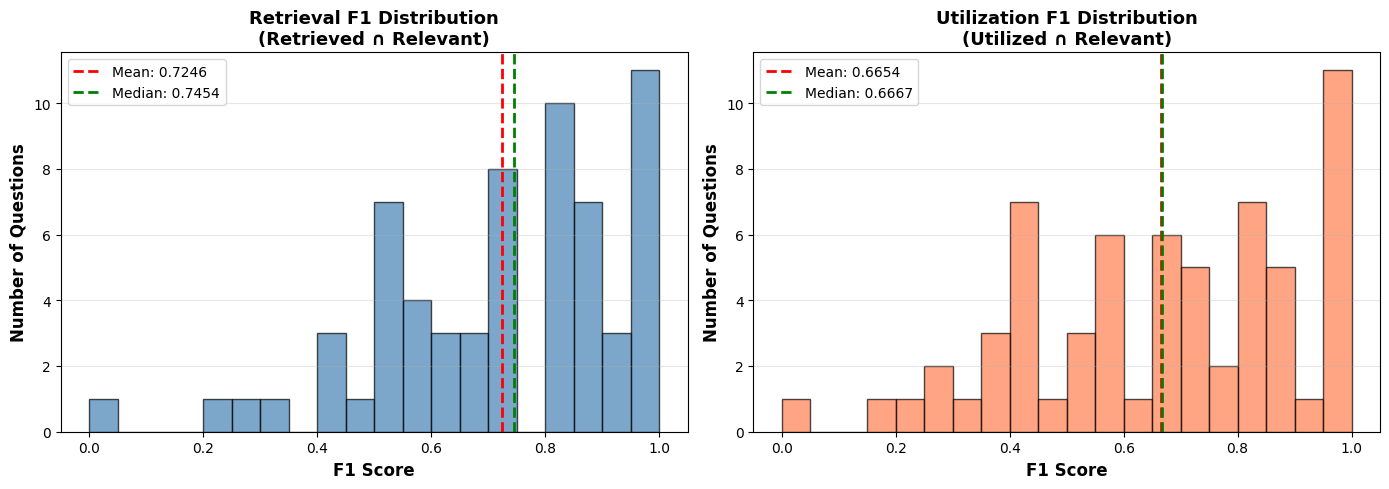


✓ Complete metrics saved to ./rag_outputs/complete_evaluation_metrics.json

FINAL EVALUATION METRICS SUMMARY

Dataset: Medical QA DataSet Test
Questions Evaluated: 64

Key Metrics:
  Overall RMSE:      0.4198  (lower is better)
  Retrieval F1:      0.7246  (higher is better)
  Utilization F1:    0.6654  (higher is better)
--------------------------------------------------------------------------------

OVERALL ASSESSMENT:
  ⚠ Needs Improvement

  - RMSE:  0.4198  (lower is better)
  - F1:    0.7246  (higher is better)

COMPREHENSIVE METRICS COMPARISON

RMSE Scores (Prediction Accuracy vs RAGBench Ground Truth):
--------------------------------------------------------------------------------
Metric                         RMSE         MAE          N Samples 
--------------------------------------------------------------------------------
Context Relevance              0.3269       0.2395       128       
Context Utilization            0.2280       0.1660       128       
Completeness  

In [ ]:
# ===============================================================================
# F1 SCORE CALCULATION FOR RAG EVALUATION
# ===============================================================================
# F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
# Measures sentence-level retrieval quality
# ===============================================================================

import numpy as np
import json
import os
from typing import Dict, List

def calculate_sentence_level_f1(
    retrieved_keys: set,
    relevant_keys: set,
    utilized_keys: set
) -> Dict[str, float]:
    """
    Calculate F1 scores for a single question

    Args:
        retrieved_keys: Set of retrieved sentence keys (e.g., {'0a', '0b', '1a'})
        relevant_keys: Set of relevant sentence keys from evaluation
        utilized_keys: Set of utilized sentence keys from evaluation

    Returns:
        Dictionary with F1 scores and components
    """
    # =====================================================
    # 1. RETRIEVAL F1: How well did retrieval capture relevant sentences?
    # =====================================================
    retrieved_and_relevant = retrieved_keys.intersection(relevant_keys)

    # Precision: Of what we retrieved, how much was relevant?
    precision_retrieval = (
        len(retrieved_and_relevant) / len(retrieved_keys)
        if len(retrieved_keys) > 0 else 0.0
    )

    # Recall: Of all relevant sentences, how many did we retrieve?
    recall_retrieval = (
        len(retrieved_and_relevant) / len(relevant_keys)
        if len(relevant_keys) > 0 else 0.0
    )

    # F1: Harmonic mean of precision and recall
    if precision_retrieval + recall_retrieval > 0:
        f1_retrieval = 2 * (precision_retrieval * recall_retrieval) / (precision_retrieval + recall_retrieval)
    else:
        f1_retrieval = 0.0

    # =====================================================
    # 2. UTILIZATION F1: How well did we utilize relevant sentences?
    # =====================================================
    utilized_and_relevant = utilized_keys.intersection(relevant_keys)

    # Precision: Of what we utilized, how much was relevant?
    precision_utilization = (
        len(utilized_and_relevant) / len(utilized_keys)
        if len(utilized_keys) > 0 else 0.0
    )

    # Recall: Of all relevant sentences, how many did we utilize?
    recall_utilization = (
        len(utilized_and_relevant) / len(relevant_keys)
        if len(relevant_keys) > 0 else 0.0
    )

    # F1: Harmonic mean
    if precision_utilization + recall_utilization > 0:
        f1_utilization = 2 * (precision_utilization * recall_utilization) / (precision_utilization + recall_utilization)
    else:
        f1_utilization = 0.0

    return {
        "retrieval_f1": f1_retrieval,
        "retrieval_precision": precision_retrieval,
        "retrieval_recall": recall_retrieval,
        "utilization_f1": f1_utilization,
        "utilization_precision": precision_utilization,
        "utilization_recall": recall_utilization,
        # Debug counts
        "num_retrieved": len(retrieved_keys),
        "num_relevant": len(relevant_keys),
        "num_utilized": len(utilized_keys),
        "num_retrieved_relevant": len(retrieved_and_relevant),
        "num_utilized_relevant": len(utilized_and_relevant)
    }


def calculate_f1_for_single_question(question_id: str, output_dir: str = "./rag_outputs"):
    """
    Calculate F1 scores for a single question

    Example:
        f1 = calculate_f1_for_single_question("39")
        print(f"Retrieval F1: {f1['retrieval_f1']:.4f}")
    """
    eval_path = os.path.join(output_dir, f"{question_id}_evaluation.json")
    retrieved_path = os.path.join(output_dir, f"{question_id}_retrieved_documents.json")

    # Load files
    with open(eval_path, 'r') as f:
        evaluation = json.load(f)

    with open(retrieved_path, 'r') as f:
        retrieved_docs = json.load(f)

    # Extract sentence keys
    retrieved_keys = set(sent[0] for doc in retrieved_docs for sent in doc)
    relevant_keys = set(evaluation.get("all_relevant_sentence_keys", []))
    utilized_keys = set(evaluation.get("all_utilized_sentence_keys", []))

    # Calculate F1
    f1_scores = calculate_sentence_level_f1(retrieved_keys, relevant_keys, utilized_keys)

    return f1_scores


# ===============================================================================
# BATCH F1 CALCULATION: Process All Questions
# ===============================================================================

def calculate_dataset_f1(output_dir: str = "./rag_outputs"):
    """
    Calculate F1 scores across entire dataset

    Returns:
        Dictionary with average F1 scores and per-question scores
    """
    all_retrieval_f1 = []
    all_utilization_f1 = []

    # Find all evaluation files
    eval_files = [f for f in os.listdir(output_dir) if f.endswith("_evaluation.json")]

    print(f"Processing {len(eval_files)} questions for F1 calculation...")

    for eval_file in eval_files:
        question_id = eval_file.replace("_evaluation.json", "")

        try:
            f1_scores = calculate_f1_for_single_question(question_id, output_dir)
            all_retrieval_f1.append(f1_scores["retrieval_f1"])
            all_utilization_f1.append(f1_scores["utilization_f1"])

        except FileNotFoundError:
            print(f"⚠ Missing files for {question_id}")
            continue
        except Exception as e:
            print(f"✗ Error processing {question_id}: {e}")
            continue

    # Calculate statistics
    retrieval_f1_array = np.array(all_retrieval_f1)
    utilization_f1_array = np.array(all_utilization_f1)

    results = {
        "retrieval_f1": {
            "mean": float(retrieval_f1_array.mean()),
            "std": float(retrieval_f1_array.std()),
            "min": float(retrieval_f1_array.min()),
            "max": float(retrieval_f1_array.max()),
            "median": float(np.median(retrieval_f1_array)),
            "n_samples": len(all_retrieval_f1),
            "all_scores": all_retrieval_f1
        },
        "utilization_f1": {
            "mean": float(utilization_f1_array.mean()),
            "std": float(utilization_f1_array.std()),
            "min": float(utilization_f1_array.min()),
            "max": float(utilization_f1_array.max()),
            "median": float(np.median(utilization_f1_array)),
            "n_samples": len(all_utilization_f1),
            "all_scores": all_utilization_f1
        }
    }

    # Print summary
    print(f"\n{'='*80}")
    print(f"DATASET-WIDE F1 SCORES (N={len(all_retrieval_f1)} questions)")
    print(f"{'='*80}")
    print(f"\n{'Metric':<25} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Median':<10}")
    print("-"*80)
    print(f"{'Retrieval F1':<25} {results['retrieval_f1']['mean']:<10.4f} "
          f"{results['retrieval_f1']['std']:<10.4f} "
          f"{results['retrieval_f1']['min']:<10.4f} "
          f"{results['retrieval_f1']['max']:<10.4f} "
          f"{results['retrieval_f1']['median']:<10.4f}")
    print(f"{'Utilization F1':<25} {results['utilization_f1']['mean']:<10.4f} "
          f"{results['utilization_f1']['std']:<10.4f} "
          f"{results['utilization_f1']['min']:<10.4f} "
          f"{results['utilization_f1']['max']:<10.4f} "
          f"{results['utilization_f1']['median']:<10.4f}")
    print("="*80)

    return results


# Run batch F1 calculation
f1_dataset_results = calculate_dataset_f1("./rag_outputs")

# Save results
with open("./rag_outputs/f1_dataset_results.json", 'w') as f:
    json.dump(f1_dataset_results, f, indent=2)

print("\n✓ F1 results saved to ./rag_outputs/f1_dataset_results.json")


# ===============================================================================
# VISUALIZATION: F1 Score Distributions
# ===============================================================================

import matplotlib.pyplot as plt

def visualize_f1_distributions(f1_results):
    """Create visualizations for F1 scores"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Retrieval F1 histogram
    ax1 = axes[0]
    scores = f1_results["retrieval_f1"]["all_scores"]
    ax1.hist(scores, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    ax1.axvline(f1_results["retrieval_f1"]["mean"],
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {f1_results["retrieval_f1"]["mean"]:.4f}')
    ax1.axvline(f1_results["retrieval_f1"]["median"],
                color='green', linestyle='--', linewidth=2,
                label=f'Median: {f1_results["retrieval_f1"]["median"]:.4f}')
    ax1.set_xlabel('F1 Score', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
    ax1.set_title('Retrieval F1 Distribution\n(Retrieved ∩ Relevant)',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

    # Utilization F1 histogram
    ax2 = axes[1]
    scores = f1_results["utilization_f1"]["all_scores"]
    ax2.hist(scores, bins=20, alpha=0.7, edgecolor='black', color='coral')
    ax2.axvline(f1_results["utilization_f1"]["mean"],
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {f1_results["utilization_f1"]["mean"]:.4f}')
    ax2.axvline(f1_results["utilization_f1"]["median"],
                color='green', linestyle='--', linewidth=2,
                label=f'Median: {f1_results["utilization_f1"]["median"]:.4f}')
    ax2.set_xlabel('F1 Score', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
    ax2.set_title('Utilization F1 Distribution\n(Utilized ∩ Relevant)',
                  fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('./rag_outputs/f1_distributions.png', dpi=150, bbox_inches='tight')
    print("\n✓ F1 distributions saved to ./rag_outputs/f1_distributions.png")
    plt.show()

# Visualize F1 distributions
visualize_f1_distributions(f1_dataset_results)


# ===============================================================================
# SAVE ALL RESULTS TO ONE FILE
# ===============================================================================

def save_all_metrics(rmse_results, f1_results, output_dir="./rag_outputs"):
    """Save comprehensive results to JSON"""

    all_results = {
        "rmse": rmse_results,
        "f1": f1_results,
        "summary": {
            "overall_rmse": rmse_results['overall']['rmse'],
            "retrieval_f1_mean": f1_results['retrieval_f1']['mean'],
            "utilization_f1_mean": f1_results['utilization_f1']['mean'],
            "n_questions_evaluated": f1_results['retrieval_f1']['n_samples']
        }
    }

    output_path = os.path.join(output_dir, "complete_evaluation_metrics.json")
    with open(output_path, 'w') as f:
        json.dump(all_results, f, indent=2)

    print(f"\n✓ Complete metrics saved to {output_path}")

    return all_results

# Save everything
all_metrics = save_all_metrics(rmse_results, f1_dataset_results)


# ===============================================================================
# QUICK SUMMARY PRINT
# ===============================================================================

print("\n" + "="*80)
print("FINAL EVALUATION METRICS SUMMARY")
print("="*80)
print(f"\nDataset: Medical QA DataSet Test")
print(f"Questions Evaluated: {f1_dataset_results['retrieval_f1']['n_samples']}")
print(f"\nKey Metrics:")
print(f"  Overall RMSE:      {rmse_results['overall']['rmse']:.4f}  (lower is better)")
print(f"  Retrieval F1:      {f1_dataset_results['retrieval_f1']['mean']:.4f}  (higher is better)")
print(f"  Utilization F1:    {f1_dataset_results['utilization_f1']['mean']:.4f}  (higher is better)")
print("-"*80)


# Combined assessment
print("\nOVERALL ASSESSMENT:")
overall_rmse = rmse_results['overall']['rmse']
retrieval_f1 = f1_dataset_results['retrieval_f1']['mean']

if overall_rmse < 0.15 and retrieval_f1 > 0.6:
    print("  ✓✓ Excellent: Low RMSE + High F1")
elif overall_rmse < 0.25 and retrieval_f1 > 0.4:
    print("  ✓ Good: Reasonable RMSE and F1")
else:
    print("  ⚠ Needs Improvement")

print(f"\n  - RMSE:  {overall_rmse:.4f}  (lower is better)")
print(f"  - F1:    {retrieval_f1:.4f}  (higher is better)")




# ===============================================================================
# COMPARISON: RMSE + F1 Side-by-Side
# ===============================================================================

def create_comparison_table(rmse_results, f1_results):
    """Create side-by-side comparison of RMSE and F1"""

    print("\n" + "="*80)
    print("COMPREHENSIVE METRICS COMPARISON")
    print("="*80)
    print("\nRMSE Scores (Prediction Accuracy vs RAGBench Ground Truth):")
    print("-"*80)
    print(f"{'Metric':<30} {'RMSE':<12} {'MAE':<12} {'N Samples':<10}")
    print("-"*80)

    for metric_name in ["context_relevance", "context_utilization", "completeness", "adherence"]:
        if metric_name in rmse_results and isinstance(rmse_results[metric_name], dict):
            r = rmse_results[metric_name]
            print(f"{metric_name.replace('_', ' ').title():<30} {r['rmse']:<12.4f} {r['mae']:<12.4f} {r['n_samples']:<10}")

    print(f"\n{'OVERALL RMSE':<30} {rmse_results['overall']['rmse']:<12.4f}")

    print("\n\nF1 Scores (Sentence-Level Retrieval Quality):")
    print("-"*80)
    print(f"{'Metric':<30} {'Mean F1':<12} {'Std':<12} {'N Samples':<10}")
    print("-"*80)
    print(f"{'Retrieval F1':<30} {f1_results['retrieval_f1']['mean']:<12.4f} "
          f"{f1_results['retrieval_f1']['std']:<12.4f} {f1_results['retrieval_f1']['n_samples']:<10}")
    print(f"{'Utilization F1':<30} {f1_results['utilization_f1']['mean']:<12.4f} "
          f"{f1_results['utilization_f1']['std']:<12.4f} {f1_results['utilization_f1']['n_samples']:<10}")
    print("="*80)


# Create comparison
create_comparison_table(rmse_results, f1_dataset_results)




In [ ]:
from google.colab import userdata
import requests
import os

# Retrieve the API key from Colab secrets
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
print("✓ API key loaded from Colab secrets")

key = os.environ.get("GROQ_API_KEY", "")
if key:
    print(f"✓ Key loaded: {key[:4]}...{key[-4:]}")
else:
    print("✗ Key not found")
    exit()

# Fetch all models
models_url = "https://api.groq.com/openai/v1/models"
headers = {
    "Authorization": f"Bearer {key}",
    "Content-Type": "application/json"
}

print(f"\n{'='*80}")
print(f"Fetching active models from GROQ API...")
print(f"{'='*80}\n")

response = requests.get(models_url, headers=headers)

if response.status_code != 200:
    print(f"✗ Error fetching models: {response.status_code}")
    print(response.text)
    exit()

models_data = response.json()

# Filter active models
active_models = [model for model in models_data.get("data", []) if model.get("active", False)]

print(f"✓ Found {len(active_models)} active models\n")
print(f"{'='*80}")
print(f"Active Models with Live Data")
print(f"{'='*80}\n")

for idx, model in enumerate(active_models, 1):
    print(f"{idx}. Model: {model.get('id')}")
    print(f"   Owner: {model.get('owned_by', 'N/A')}")
    print(f"   Context Window: {model.get('context_window', 'N/A'):,} tokens" if isinstance(model.get('context_window'), int) else f"   Context Window: {model.get('context_window', 'N/A')}")
    print(f"   Created: {model.get('created', 'N/A')}")
    print(f"   Active: {model.get('active', False)}")

    # Check if rate limit info is available in the response
    if 'rate_limits' in model:
        print(f"   Rate Limits:")
        for limit_type, value in model['rate_limits'].items():
            print(f"     • {limit_type}: {value}")
    else:
        print(f"   Rate Limits: Check headers during actual API calls")
    print()

print(f"\n{'='*80}")
print(f"💡 Note: Individual model rate limits are returned in response headers")
print(f"   when making actual API calls to /v1/chat/completions")
print(f"\n   Header fields to check:")
print(f"   • x-ratelimit-limit-requests")
print(f"   • x-ratelimit-remaining-requests")
print(f"   • x-ratelimit-limit-tokens")
print(f"   • x-ratelimit-remaining-tokens")
print(f"{'='*80}")

# Print raw response for inspection
print(f"\n{'='*80}")
print(f"Sample Model Data Structure:")
print(f"{'='*80}\n")
if active_models:
    import json
    print(json.dumps(active_models[0], indent=2))


✓ API key loaded from Colab secrets
✓ Key loaded: gsk_...sZaY

Fetching active models from GROQ API...

✓ Found 20 active models

Active Models with Live Data

1. Model: qwen/qwen3-32b
   Owner: Alibaba Cloud
   Context Window: 131,072 tokens
   Created: 1748396646
   Active: True
   Rate Limits: Check headers during actual API calls

2. Model: whisper-large-v3
   Owner: OpenAI
   Context Window: 448 tokens
   Created: 1693721698
   Active: True
   Rate Limits: Check headers during actual API calls

3. Model: meta-llama/llama-4-scout-17b-16e-instruct
   Owner: Meta
   Context Window: 131,072 tokens
   Created: 1743874824
   Active: True
   Rate Limits: Check headers during actual API calls

4. Model: whisper-large-v3-turbo
   Owner: OpenAI
   Context Window: 448 tokens
   Created: 1728413088
   Active: True
   Rate Limits: Check headers during actual API calls

5. Model: meta-llama/llama-4-maverick-17b-128e-instruct
   Owner: Meta
   Context Window: 131,072 tokens
   Created: 174387715

In [ ]:
# ===============================================================================
# DIAGNOSTIC SCRIPT: Analyze RAGBench Results Directories
# ===============================================================================
#
# Run this first to understand:
# 1. Which results directory has data
# 2. What file formats are being used
# 3. What fields are available
#
# ===============================================================================

import os
import json
from collections import defaultdict

# Directories to check
DIRECTORIES_TO_CHECK = [
    "/content/drive/MyDrive/ragbench_olv1",
    "/content/drive/MyDrive/ragbench_v2",
    "/content/drive/MyDrive/ragbench/results/final_multi_domain_answers",
    "/content/drive/MyDrive/ragbench/results/evaluation_with_llm_judge"
]

DOMAINS = [
    "medical_covidqa",
    "medical_pubmedqa",
    "finance_finqa",
    "finance_tatqa",
    "support_techqa",
    "general_hotpotqa",
    "legal_cuad"
]

print("="*80)
print("RAGBENCH RESULTS DIRECTORY DIAGNOSTIC")
print("="*80)

# ===============================================================================
# STEP 1: Check which directories exist and what's inside
# ===============================================================================

print("\n" + "="*80)
print("STEP 1: Directory Structure Analysis")
print("="*80)

for base_dir in DIRECTORIES_TO_CHECK:
    print(f"\n📁 {base_dir}")

    if not os.path.exists(base_dir):
        print("   ❌ Directory does not exist")
        continue

    # List contents
    try:
        contents = os.listdir(base_dir)
        print(f"   ✓ Exists with {len(contents)} items")

        # Check for domain subdirectories
        domains_found = []
        other_items = []

        for item in contents:
            item_path = os.path.join(base_dir, item)
            if os.path.isdir(item_path):
                # Check if it matches a domain
                is_domain = any(domain in item for domain in DOMAINS) or item in DOMAINS
                if is_domain:
                    domains_found.append(item)
                else:
                    other_items.append(f"{item}/ (dir)")
            else:
                other_items.append(item)

        if domains_found:
            print(f"   Domain subdirectories found: {len(domains_found)}")
            for d in domains_found[:5]:
                domain_path = os.path.join(base_dir, d)
                domain_files = os.listdir(domain_path) if os.path.isdir(domain_path) else []
                print(f"      - {d}: {len(domain_files)} files")

        if other_items:
            print(f"   Other items: {other_items[:5]}")

    except Exception as e:
        print(f"   ⚠️ Error reading directory: {e}")

# ===============================================================================
# STEP 2: Analyze file formats in each domain
# ===============================================================================

print("\n" + "="*80)
print("STEP 2: File Format Analysis")
print("="*80)

def analyze_file_format(filepath):
    """Analyze the format of a JSON file."""
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)

        if isinstance(data, list):
            if len(data) == 0:
                return "empty_list"
            sample = data[0]
            if isinstance(sample, dict):
                return f"list_of_dicts: keys={list(sample.keys())[:5]}"
            elif isinstance(sample, list):
                if len(sample) > 0:
                    inner = sample[0]
                    if isinstance(inner, list) and len(inner) >= 2:
                        return f"list_of_lists_of_pairs: e.g. [['{inner[0]}', '...'], ...]"
                    elif isinstance(inner, dict):
                        return f"nested_list_of_dicts: keys={list(inner.keys())[:5]}"
                return f"list_of_lists"
            else:
                return f"list_of_{type(sample).__name__}"
        elif isinstance(data, dict):
            return f"dict: keys={list(data.keys())[:10]}"
        else:
            return f"unknown: {type(data).__name__}"
    except Exception as e:
        return f"error: {str(e)[:50]}"

for base_dir in DIRECTORIES_TO_CHECK:
    if not os.path.exists(base_dir):
        continue

    print(f"\n📁 {base_dir}")

    for domain in DOMAINS:
        domain_path = os.path.join(base_dir, domain)
        if not os.path.exists(domain_path):
            continue

        print(f"\n   📂 {domain}:")

        files = os.listdir(domain_path)

        # Categorize files
        answer_files = [f for f in files if '_answer.txt' in f]
        structured_files = [f for f in files if '_structured_output' in f]
        retrieved_files = [f for f in files if '_retrieved_documents.json' in f]
        eval_files = [f for f in files if '_evaluation.json' in f]
        index_files = [f for f in files if 'index' in f.lower() and f.endswith('.json')]

        print(f"      Answer files: {len(answer_files)}")
        print(f"      Structured output files: {len(structured_files)}")
        print(f"      Retrieved documents files: {len(retrieved_files)}")
        print(f"      Evaluation files: {len(eval_files)}")
        print(f"      Index files: {len(index_files)}")

        # Analyze format of first retrieved documents file
        if retrieved_files:
            sample_file = os.path.join(domain_path, retrieved_files[0])
            format_info = analyze_file_format(sample_file)
            print(f"      Retrieved docs format: {format_info}")

            # Show sample content
            try:
                with open(sample_file, 'r') as f:
                    data = json.load(f)
                if isinstance(data, list) and len(data) > 0:
                    sample = data[0]
                    if isinstance(sample, dict):
                        print(f"      Sample keys: {list(sample.keys())}")
                        if 'metadata' in sample:
                            print(f"      Metadata keys: {list(sample['metadata'].keys())}")
                    elif isinstance(sample, list) and len(sample) > 0:
                        print(f"      Sample inner item: {sample[0][:100] if isinstance(sample[0], str) else sample[0]}")
            except:
                pass

        # Analyze format of first evaluation file
        if eval_files:
            sample_file = os.path.join(domain_path, eval_files[0])
            format_info = analyze_file_format(sample_file)
            print(f"      Evaluation format: {format_info}")

# ===============================================================================
# STEP 3: Check for saved indexes
# ===============================================================================

print("\n" + "="*80)
print("STEP 3: Checking for Saved Indexes")
print("="*80)

index_locations = [
    "/content/drive/MyDrive/ragbench/results/indexes",
    "/content/drive/MyDrive/ragbench_olv1/indexes",
    "/content/drive/MyDrive/ragbench_v2/indexes",
]

for loc in index_locations:
    print(f"\n📁 {loc}")
    if os.path.exists(loc):
        files = os.listdir(loc)
        print(f"   ✓ Found {len(files)} files: {files[:10]}")
    else:
        print("   ❌ Does not exist")

# Also check for index files in base directories
for base_dir in DIRECTORIES_TO_CHECK:
    if os.path.exists(base_dir):
        files = [f for f in os.listdir(base_dir) if 'index' in f.lower()]
        if files:
            print(f"\n   Index files in {base_dir}: {files}")

# ===============================================================================
# STEP 4: Sample Question ID Analysis
# ===============================================================================

print("\n" + "="*80)
print("STEP 4: Question ID Format Analysis")
print("="*80)

from datasets import load_dataset

DOMAIN_MAPPING = {
    "medical_covidqa": "covidqa",
    "finance_finqa": "finqa",
    "support_techqa": "techqa",
    "general_hotpotqa": "hotpotqa",
    "legal_cuad": "cuad"
}

for domain, ragbench_name in DOMAIN_MAPPING.items():
    print(f"\n📊 {domain} ({ragbench_name}):")

    # Get sample IDs from RAGBench
    try:
        dataset = load_dataset("galileo-ai/ragbench", ragbench_name, split="test")
        gt_ids = [str(row["id"]) for row in list(dataset)[:5]]
        print(f"   Ground truth IDs (first 5): {gt_ids}")
    except Exception as e:
        print(f"   Error loading ground truth: {e}")
        continue

    # Get sample IDs from results
    for base_dir in DIRECTORIES_TO_CHECK:
        domain_path = os.path.join(base_dir, domain)
        if os.path.exists(domain_path):
            files = [f for f in os.listdir(domain_path) if '_retrieved_documents.json' in f]
            if files:
                result_ids = [f.replace('_retrieved_documents.json', '') for f in files[:5]]
                print(f"   Result IDs from {base_dir.split('/')[-1]}: {result_ids}")

                # Check for matches
                gt_set = set([str(row["id"]) for row in dataset])
                result_set = set([f.replace('_retrieved_documents.json', '') for f in files])

                matches = gt_set.intersection(result_set)
                print(f"      Matching IDs: {len(matches)}/{len(result_set)}")

print("\n" + "="*80)
print("DIAGNOSTIC COMPLETE")
print("="*80)
print("""
Next steps:
1. Run the corrected RMSE calculation with the correct results directory
2. If no matches found, check if IDs need format conversion
3. Ensure retrieved_documents.json contains proper sentence keys
""")

RAGBENCH RESULTS DIRECTORY DIAGNOSTIC

STEP 1: Directory Structure Analysis

📁 /content/drive/MyDrive/ragbench_olv1
   ✓ Exists with 1 items
   Other items: ['results/ (dir)']

📁 /content/drive/MyDrive/ragbench_v2
   ✓ Exists with 3 items
   Other items: ['results/ (dir)', 'dataset_analysis/ (dir)', 'rag_experiments/ (dir)']

📁 /content/drive/MyDrive/ragbench/results/final_multi_domain_answers
   ❌ Directory does not exist

📁 /content/drive/MyDrive/ragbench/results/evaluation_with_llm_judge
   ❌ Directory does not exist

STEP 2: File Format Analysis

📁 /content/drive/MyDrive/ragbench_olv1

📁 /content/drive/MyDrive/ragbench_v2

STEP 3: Checking for Saved Indexes

📁 /content/drive/MyDrive/ragbench/results/indexes
   ❌ Does not exist

📁 /content/drive/MyDrive/ragbench_olv1/indexes
   ❌ Does not exist

📁 /content/drive/MyDrive/ragbench_v2/indexes
   ❌ Does not exist

STEP 4: Question ID Format Analysis

📊 medical_covidqa (covidqa):


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

covidqa/train-00000-of-00001.parquet:   0%|          | 0.00/4.20M [00:00<?, ?B/s]

covidqa/test-00000-of-00001.parquet:   0%|          | 0.00/854k [00:00<?, ?B/s]

...

cuad/test-00000-of-00001.parquet:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/510 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/510 [00:00<?, ? examples/s]

   Ground truth IDs (first 5): ['SPARKLINGSPRINGWATERHOLDINGSLTD_07_03_2002-EX-10.13-SOFTWARE LICENSE AND MAINTENANCE AGREEMENT__Volume Restriction', 'EMERALDHEALTHTHERAPEUTICSINC_06_10_2020-EX-4.5-CONSULTING AGREEMENT - DR. GAETANO MORELLO N.D. INC.__Rofr/Rofo/Rofn', 'MEDALISTDIVERSIFIEDREIT,INC_05_18_2020-EX-10.1-CONSULTING AGREEMENT__Warranty Duration', 'AULAMERICANUNITTRUST_04_24_2020-EX-99.8.77-SERVICING AGREEMENT__Joint Ip Ownership', 'GSITECHNOLOGYINC_11_16_2009-EX-10.2-INTELLECTUAL PROPERTY AGREEMENT between SONY ELECTRONICS INC. and GSI TECHNOLOGY, INC.__Non-Compete']

DIAGNOSTIC COMPLETE

Next steps:
1. Run the corrected RMSE calculation with the correct results directory
2. If no matches found, check if IDs need format conversion
3. Ensure retrieved_documents.json contains proper sentence keys



In [ ]:
# ===============================================================================
# DEEP DIAGNOSTIC - Find RAGBench Results in Nested Directories
# ===============================================================================

import os
import json

# Base directories to explore
BASE_DIRS = [
    "/content/drive/MyDrive/ragbench_olv1",
    "/content/drive/MyDrive/ragbench_v2",
]

DOMAINS = [
    "medical_covidqa",
    "finance_finqa",
    "support_techqa",
    "general_hotpotqa",
    "legal_cuad"
]

print("="*80)
print("DEEP DIRECTORY EXPLORATION")
print("="*80)

def explore_directory(path, depth=0, max_depth=4):
    """Recursively explore directory structure."""
    if depth > max_depth:
        return

    indent = "  " * depth

    try:
        items = os.listdir(path)
    except:
        return

    # Check for domain folders or retrieved documents
    for item in items:
        item_path = os.path.join(path, item)

        if os.path.isdir(item_path):
            # Check if this is a domain directory
            is_domain = any(domain in item for domain in DOMAINS)

            if is_domain:
                # Count files in domain directory
                try:
                    files = os.listdir(item_path)
                    retrieved = [f for f in files if '_retrieved_documents.json' in f]
                    answer = [f for f in files if '_answer.txt' in f]
                    evaluation = [f for f in files if '_evaluation.json' in f]

                    print(f"{indent}📂 {item}:")
                    print(f"{indent}   Path: {item_path}")
                    print(f"{indent}   Retrieved docs: {len(retrieved)}")
                    print(f"{indent}   Answer files: {len(answer)}")
                    print(f"{indent}   Evaluation files: {len(evaluation)}")

                    if retrieved:
                        # Show sample file
                        sample = os.path.join(item_path, retrieved[0])
                        print(f"{indent}   Sample: {retrieved[0]}")

                        # Analyze format
                        try:
                            with open(sample, 'r') as f:
                                data = json.load(f)
                            if isinstance(data, list) and len(data) > 0:
                                first = data[0]
                                if isinstance(first, dict):
                                    print(f"{indent}   Format: list of dicts with keys: {list(first.keys())[:5]}")
                                    if 'metadata' in first:
                                        print(f"{indent}   Metadata keys: {list(first['metadata'].keys())}")
                                elif isinstance(first, list):
                                    print(f"{indent}   Format: nested list, inner sample: {first[0] if first else 'empty'}")
                        except Exception as e:
                            print(f"{indent}   Error reading sample: {e}")
                    print()
                except:
                    pass
            else:
                # Not a domain dir, explore deeper
                print(f"{indent}📁 {item}/")
                explore_directory(item_path, depth + 1, max_depth)

        elif item.endswith('.json') and depth > 0:
            # Check for index files or other important files
            if 'index' in item.lower() or 'summary' in item.lower() or 'config' in item.lower():
                print(f"{indent}📄 {item}")

# Explore each base directory
for base_dir in BASE_DIRS:
    print(f"\n{'='*80}")
    print(f"Exploring: {base_dir}")
    print("="*80)

    if os.path.exists(base_dir):
        explore_directory(base_dir, depth=0)
    else:
        print(f"  ❌ Directory does not exist")

# ===============================================================================
# Also check for any _retrieved_documents.json files anywhere
# ===============================================================================

print("\n" + "="*80)
print("SEARCHING FOR ALL retrieved_documents.json FILES")
print("="*80)

def find_files(directory, pattern, results=None, max_results=20):
    """Find files matching pattern."""
    if results is None:
        results = []

    if len(results) >= max_results:
        return results

    try:
        for item in os.listdir(directory):
            if len(results) >= max_results:
                break

            item_path = os.path.join(directory, item)

            if os.path.isfile(item_path) and pattern in item:
                results.append(item_path)
            elif os.path.isdir(item_path):
                find_files(item_path, pattern, results, max_results)
    except:
        pass

    return results

for base_dir in BASE_DIRS:
    print(f"\n📁 {base_dir}:")
    if os.path.exists(base_dir):
        found = find_files(base_dir, "_retrieved_documents.json", max_results=10)
        if found:
            for f in found[:5]:
                print(f"  ✓ {f}")
            if len(found) > 5:
                print(f"  ... and {len(found) - 5} more")
        else:
            print("  No retrieved_documents.json files found")

print("\n" + "="*80)
print("DONE - Use the paths above to configure RMSE calculation")
print("="*80)

DEEP DIRECTORY EXPLORATION

Exploring: /content/drive/MyDrive/ragbench_olv1
📁 results/
  📁 medical/
  📁 chunking_experiments/
  📁 optimized_evaluation/
  📁 multi_domain_evaluation/
    📄 best_configs_per_domain_v1_backup.json
    📄 best_configs_per_domain_v2.json
    📄 best_configs_per_domain.json
  📁 final_multi_domain_answers_todelete_1/
    📁 retrieved_docs/
      📂 medical_covidqa:
         Path: /content/drive/MyDrive/ragbench_olv1/results/final_multi_domain_answers_todelete_1/retrieved_docs/medical_covidqa
         Retrieved docs: 30
         Answer files: 0
         Evaluation files: 0
         Sample: 358_retrieved_documents.json
         Format: list of dicts with keys: ['page_content', 'metadata']
         Metadata keys: ['id', 'source', 'question', 'domain', 'chunk_technique', 'chunk_index', 'chunk_size_config', 'rerank_score']

      📁 medical_pubmedqa/
    📁 answers/
  📁 .ipynb_checkpoints/
  📁 final_multi_domain_answers/
    📁 medical_pubmedqa/
    📄 medical_pubmedqa_summ

In [ ]:
# ============================================================================
# CELL 33: COMPLETE STANDALONE LLM EVALUATION (FIXED DEPENDENCY ISSUES)
# Run this without any prior cells - includes all setup
# ============================================================================

# ============================================================================
# STEP 1: INSTALL REQUIRED PACKAGES (COMPATIBLE VERSIONS)
# ============================================================================

# Uninstall conflicting packages
!pip uninstall -y langchain langchain-core langchain-community langchain-groq 2>/dev/null

# Install compatible versions that work together
!pip install --quiet --upgrade \
    langchain-core==0.3.29 \
    langchain-groq==0.2.1 \
    langchain==0.3.14 \
    langchain-community==0.3.14

!pip install --quiet datasets tqdm

print("✅ Packages installed successfully!")

# ============================================================================
# STEP 2: RESTART RUNTIME WARNING
# ============================================================================

print("\n" + "="*80)
print("⚠️  IMPORTANT: After package installation, you may need to:")
print("   1. Click 'Runtime' → 'Restart runtime' in the menu")
print("   2. Then re-run this cell")
print("="*80 + "\n")

# ============================================================================
# STEP 3: MOUNT GOOGLE DRIVE
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================================
# STEP 4: SET UP API KEY
# ============================================================================

from google.colab import userdata
import os

# Retrieve the API key from Colab secrets
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
print(f"✅ GROQ API Key loaded: {os.environ['GROQ_API_KEY'][:10]}...")

# ============================================================================
# STEP 5: IMPORTS
# ============================================================================

import json
from tqdm import tqdm

try:
    from langchain_groq import ChatGroq
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import JsonOutputParser
    print("✅ All imports successful!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("\n🔄 Please RESTART RUNTIME and re-run this cell:")
    print("   Menu → Runtime → Restart runtime")
    raise

# ============================================================================
# CONFIGURATION
# ============================================================================

DOMAINS_TO_EVALUATE = [
    'medical_covidqa',
    'finance_finqa',
    'support_techqa',
    'general_hotpotqa',
    'legal_cuad',
]

# Paths - UPDATE THESE TO MATCH YOUR DIRECTORY
ANSWERS_BASE_DIR = "/content/drive/MyDrive/ragbench_v2/results/final_multi_domain_answers"
EVAL_OUTPUT_DIR = "/content/drive/MyDrive/ragbench_v2/results/evaluation_with_llm_judge"
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# LLM for evaluation
EVAL_LLM_MODEL = "llama-3.3-70b-versatile"
EVAL_LLM_TEMP = 0

print(f"{'='*80}")
print(f"📊 RAGBENCH EVALUATION WITH LLM JUDGE")
print(f"{'='*80}")
print(f"Evaluator model: {EVAL_LLM_MODEL}")
print(f"Domains: {len(DOMAINS_TO_EVALUATE)}")
print(f"Input: {ANSWERS_BASE_DIR}")
print(f"Output: {EVAL_OUTPUT_DIR}")
print(f"{'='*80}\n")

# ============================================================================
# INITIALIZE EVALUATION LLM
# ============================================================================

eval_llm = ChatGroq(
    model=EVAL_LLM_MODEL,
    temperature=EVAL_LLM_TEMP,
    max_tokens=8192
)

print(f"✅ Initialized evaluation LLM: {EVAL_LLM_MODEL}\n")

# ============================================================================
# EVALUATION PROMPT
# ============================================================================

EVALUATION_PROMPT = """You are an expert evaluator analyzing the quality and attribution of a RAG (Retrieval-Augmented Generation) system's response.

Given:
1. Question: {question}
2. Generated Answer: {answer}
3. Retrieved Documents: {retrieved_docs}

Analyze the response and provide a detailed evaluation in JSON format with the following fields:

1. "relevance_explanation": Explain which documents are relevant to answering the question and why.

2. "all_relevant_sentence_keys": List all document IDs or sentence keys that contain information relevant to the question.

3. "overall_supported_explanation": Detailed explanation of whether the answer is supported by the retrieved documents. Analyze each claim in the answer.

4. "overall_supported": Boolean - is the entire answer supported by the documents?

5. "sentence_support_information": Array of objects, one for each sentence in the answer:
   - "response_sentence_key": Label for the sentence (a, b, c, etc.)
   - "explanation": Why this sentence is or isn't supported
   - "supporting_sentence_keys": Array of document IDs that support this sentence
   - "fully_supported": Boolean - is this sentence fully supported?

6. "all_utilized_sentence_keys": List of all document IDs actually used in the answer.

Return ONLY valid JSON, no additional text.

Example format:
{{
  "relevance_explanation": "Document X contains...",
  "all_relevant_sentence_keys": ["doc1", "doc2"],
  "overall_supported_explanation": "The answer claims... which is supported by...",
  "overall_supported": true,
  "sentence_support_information": [
    {{
      "response_sentence_key": "a",
      "explanation": "This sentence...",
      "supporting_sentence_keys": ["doc1"],
      "fully_supported": true
    }}
  ],
  "all_utilized_sentence_keys": ["doc1", "doc2"]
}}"""

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_question_data(question_id: str, domain: str) -> dict:
    """Load answer, structured output, and retrieved docs."""

    base_path = os.path.join(ANSWERS_BASE_DIR, domain)

    # Load answer
    answer_file = os.path.join(base_path, f"{question_id}_answer.txt")
    answer = None
    if os.path.exists(answer_file):
        with open(answer_file, 'r', encoding='utf-8') as f:
            content = f.read()
            lines = content.split('\n')
            answer_start = next((i for i, line in enumerate(lines) if line.startswith('Answer:')), None)
            if answer_start is not None:
                answer = '\n'.join(lines[answer_start + 1:]).strip()

    # Load structured output
    structured_file = os.path.join(base_path, f"{question_id}_structured_output.txt")
    structured = None
    if os.path.exists(structured_file):
        try:
            with open(structured_file, 'r', encoding='utf-8') as f:
                structured = json.load(f)
        except:
            structured = None

    # Load retrieved documents
    docs_file = os.path.join(base_path, f"{question_id}_retrieved_documents.json")
    retrieved_docs = None
    if os.path.exists(docs_file):
        try:
            with open(docs_file, 'r', encoding='utf-8') as f:
                retrieved_docs = json.load(f)
        except:
            retrieved_docs = None

    return {
        'answer': answer,
        'structured': structured,
        'retrieved_docs': retrieved_docs,
        'files_exist': all([answer, structured, retrieved_docs])
    }

def format_retrieved_docs_for_eval(retrieved_docs: list) -> str:
    """Format retrieved documents for evaluation prompt."""

    formatted = []
    for i, doc in enumerate(retrieved_docs):
        if isinstance(doc, dict):
            doc_id = doc.get('metadata', {}).get('chunk_index', f'doc_{i}')
            content = doc.get('page_content', doc.get('content', ''))
        else:
            doc_id = f'doc_{i}'
            content = str(doc)

        formatted.append(f"[{doc_id}]\n{content}\n")

    return "\n".join(formatted)

def evaluate_answer_with_llm(question: str, answer: str, retrieved_docs: list) -> dict:
    """Use LLM to evaluate answer attribution and support."""

    # Format documents
    docs_text = format_retrieved_docs_for_eval(retrieved_docs)

    # Create prompt
    prompt = ChatPromptTemplate.from_template(EVALUATION_PROMPT)

    # Create chain with JSON parser
    parser = JsonOutputParser()
    chain = prompt | eval_llm | parser

    try:
        evaluation = chain.invoke({
            "question": question,
            "answer": answer,
            "retrieved_docs": docs_text
        })

        return evaluation

    except Exception as e:
        print(f"    ⚠️  Evaluation failed: {str(e)[:100]}")
        return None

# ============================================================================
# MAIN EVALUATION LOOP
# ============================================================================

print(f"{'='*80}")
print(f"🚀 STARTING EVALUATION")
print(f"{'='*80}\n")

evaluation_stats = {}

for domain_key in DOMAINS_TO_EVALUATE:

    print(f"\n{'─'*80}")
    print(f"📊 Domain: {domain_key.upper()}")
    print(f"{'─'*80}")

    # Get list of questions from directory
    domain_dir = os.path.join(ANSWERS_BASE_DIR, domain_key)
    if not os.path.exists(domain_dir):
        print(f"⚠️  Directory not found: {domain_dir}")
        continue

    # Find all answer files
    answer_files = [f for f in os.listdir(domain_dir) if f.endswith('_answer.txt')]
    question_ids = [f.replace('_answer.txt', '') for f in answer_files]

    print(f"Found {len(question_ids)} questions")

    # Create domain output directory
    domain_eval_dir = os.path.join(EVAL_OUTPUT_DIR, domain_key)
    os.makedirs(domain_eval_dir, exist_ok=True)

    successful = 0
    failed = 0
    skipped = 0

    # Evaluate each question
    for question_id in tqdm(question_ids, desc=f"Evaluating {domain_key}"):

        # Skip if already evaluated
        eval_file = os.path.join(domain_eval_dir, f"{question_id}_evaluation.json")
        if os.path.exists(eval_file):
            skipped += 1
            successful += 1
            continue

        # Load question data
        data = load_question_data(question_id, domain_key)

        if not data['files_exist']:
            print(f"    ⚠️  Missing files for {question_id}")
            failed += 1
            continue

        question = data['structured'].get('question', '')
        answer = data['answer']
        retrieved_docs = data['retrieved_docs']

        # Evaluate with LLM
        evaluation = evaluate_answer_with_llm(question, answer, retrieved_docs)

        if evaluation is None:
            failed += 1
            continue

        # Add metadata
        evaluation['_metadata'] = {
            'model': EVAL_LLM_MODEL,
            'question_id': question_id,
            'domain': domain_key,
            'input_file': os.path.join(domain_dir, f"{question_id}_structured_output.txt"),
        }

        # Save evaluation
        with open(eval_file, 'w', encoding='utf-8') as f:
            json.dump(evaluation, f, indent=2, ensure_ascii=False)

        successful += 1

    # Track stats
    evaluation_stats[domain_key] = {
        'total': len(question_ids),
        'successful': successful,
        'failed': failed,
        'skipped': skipped,
        'success_rate': successful / len(question_ids) * 100 if len(question_ids) > 0 else 0
    }

    print(f"\n✅ {domain_key}: {successful}/{len(question_ids)} evaluated")
    print(f"   (Skipped {skipped} already done, {failed} failed)")

# ============================================================================
# SAVE EVALUATION SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print(f"💾 SAVING EVALUATION SUMMARY")
print(f"{'='*80}\n")

summary = {
    'evaluator_model': EVAL_LLM_MODEL,
    'domains_evaluated': list(evaluation_stats.keys()),
    'total_evaluations': sum(s['successful'] for s in evaluation_stats.values()),
    'total_failed': sum(s['failed'] for s in evaluation_stats.values()),
    'average_success_rate': sum(s['success_rate'] for s in evaluation_stats.values()) / len(evaluation_stats) if evaluation_stats else 0,
    'per_domain_stats': evaluation_stats
}

summary_file = os.path.join(EVAL_OUTPUT_DIR, 'evaluation_summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Summary saved: {summary_file}")

# ============================================================================
# FINAL REPORT
# ============================================================================

print(f"\n{'='*80}")
print(f"📊 EVALUATION COMPLETE")
print(f"{'='*80}")
print(f"Evaluator: {EVAL_LLM_MODEL}")
print(f"Domains: {len(evaluation_stats)}")
print(f"Total evaluations: {summary['total_evaluations']}")
print(f"Failed: {summary['total_failed']}")
print(f"Success rate: {summary['average_success_rate']:.1f}%")

print(f"\nPer-domain breakdown:")
for domain, stats in evaluation_stats.items():
    print(f"  {domain}:")
    print(f"    Total: {stats['total']}")
    print(f"    Successful: {stats['successful']} ({stats['success_rate']:.1f}%)")
    print(f"    Skipped (already done): {stats['skipped']}")
    print(f"    Failed: {stats['failed']}")

print(f"\n{'='*80}")
print(f"✅ EVALUATION FILES READY!")
print(f"{'='*80}\n")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-classic 1.0.1 requires langchain-core<2.0.0,>=1.2.5, but you have langchain-core 0.3.29 which is incompatible.
langchain-classic 1.0.1 requires langchain-text-splitters<2.0.0,>=1.1.0, but you have langchain-text-splitters 0.3.5 which is incompatible.
langchain-huggingface 1.2.0 requires langchain-core<2.0.0,>=1.2.0, but you have langchain-core 0.3.29 which is incompatible.
langgraph-prebuilt 1.0.7 requires langchain-co

TypeError: Cannot create a consistent method resolution
order (MRO) for bases Generic, ABC

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
import os
import json
from tqdm import tqdm

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
print(f"✅ GROQ API Key loaded: {os.environ['GROQ_API_KEY'][:10]}...")

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

print("✅ All imports successful!")

Mounted at /content/drive
✅ GROQ API Key loaded: gsk_L0c2n9...


ModuleNotFoundError: No module named 'langchain_groq'